In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import seaborn as sns

import sys
sys.path.append("../")

def retime(df):
    """
    Recalculate segment time, treating the entire dataframe as one segment.

    Args:
        df (pd.DataFrame): Measurement data. Includes a column
                           'Segment Time, S'

    Returns:
        pd.DataFrame: Dataframe where 'Segment Time, S' is reindexed
                      to start from 0.
    """
    df_ = df.copy().reset_index(drop=True)
    df_["Segment Time, S"] = df_["Total Time, S"] - df_.loc[0, "Total Time, S"]
    return df_

hdf = pd.HDFStore('../../data/data_raw.h5', mode='r')
keys = hdf.keys()

In [3]:
idx_A = np.nonzero(["_A_" in key for key in keys])
df = hdf.get(keys[idx_A[0][0]])

In [3]:
segments_of_interest = [
    "Charge depleting cycle",
    "Charge sustaining cycle",
    'Rate test C/2 cycle charge CC',
    'PsRP 1 C/2 diagnostic cycle charge',
    'PsRP 2 C/2 diagnostic cycle charge',
    'Rate test 1C cycle charge CC',
    'PsRP 1 1C diagnostic cycle charge',
    'PsRP 2 1C diagnostic cycle charge',
]

Feature processing plan:
- "Charge depleting cycle",
    - has 10 minute repeats of power control
    - split into 10 minute windows (every 600 rows exactly)
    - for each window, extract final 2 minutes [:-120] for held out test set input
    - extract 5 random 120s windows from the first 8 minutes for training set input
    - target is C/3 discharge capacity
- "Charge sustaining cycle",
    - last 30 minutes pull out for held out test set input
    - first 1.5 hours, pull out 5 random 30 minute segments
- 'Rate test C/2 cycle charge CC',
    - grab 10x random 15 minute windows
- 'PsRP 1 C/2 diagnostic cycle charge',
    - grab 10x random 15 minute windows
- 'PsRP 2 C/2 diagnostic cycle charge',
    - grab 10x random 15 minute windows
- 'Rate test 1C cycle charge CC',
    - grab 10x random 8 minute windows
- 'PsRP 1 1C diagnostic cycle charge',
    - grab 10x random 8 minute windows
- 'PsRP 2 1C diagnostic cycle charge',
    - grab 10x random 8 minute windows

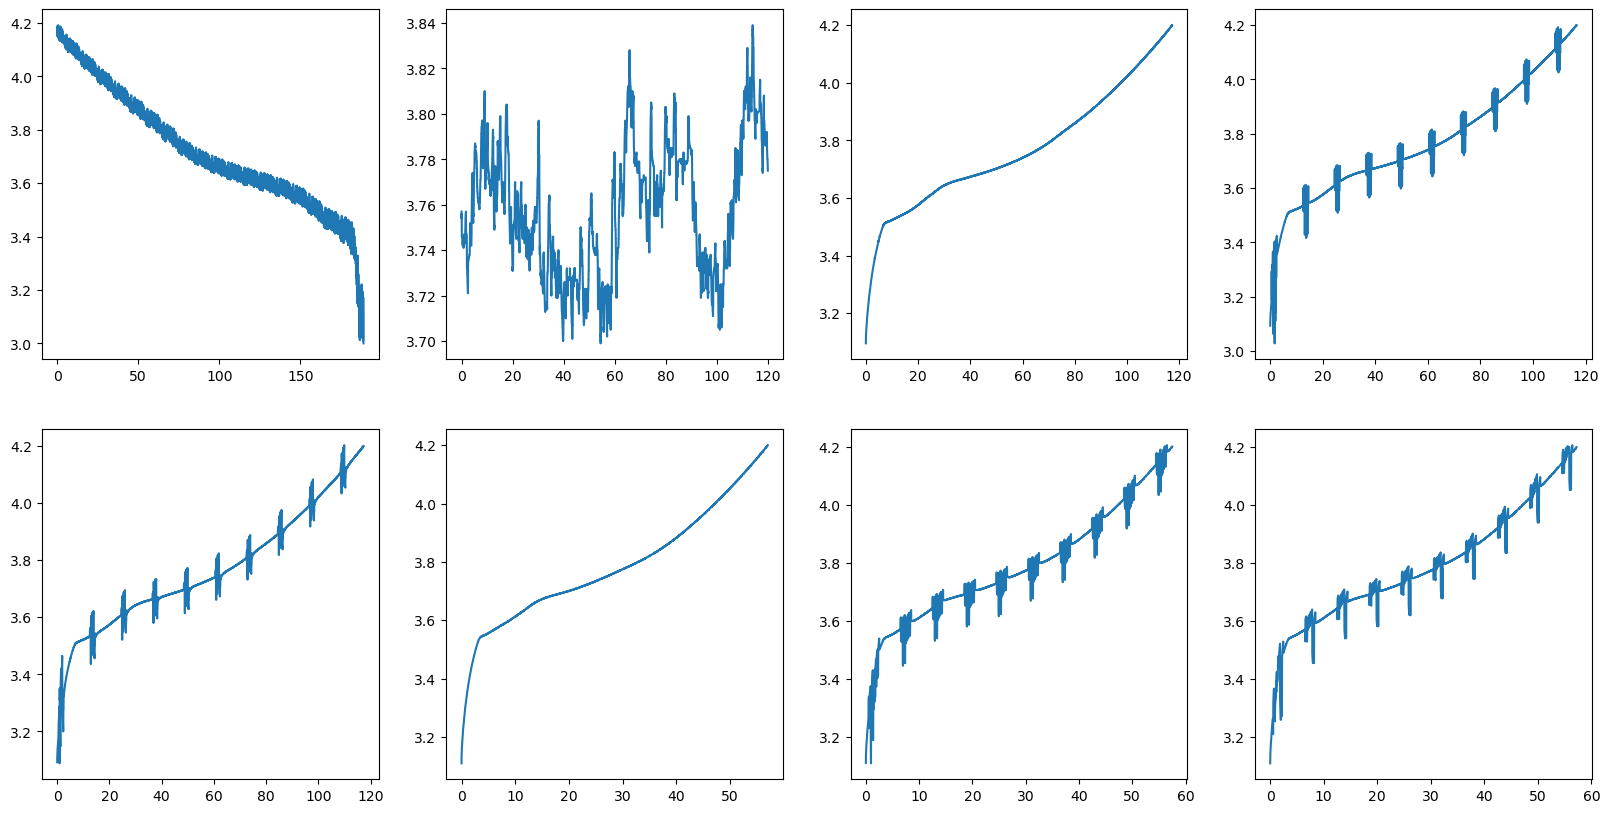

In [5]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
ax = ax.flatten()
for i, segment in enumerate(segments_of_interest):
    # filter df for any rows where the col 'Segment Description' contains segment
    df_segment = df.loc[[segment in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc for seg_desc in df['Segment Description']]]
    df_segment = retime(df_segment)
    ax[i].plot(df_segment['Segment Time, S'] / 60, df_segment['Voltage, V'])

In [6]:
df[df['Segment Description'].str.contains('Charge depleting cycle')]

,"Total Time, S",Cycle,Loop Counter #1,Loop Counter #2,Loop Counter #3,Step,"Step Time, S","Current, A","Voltage, V","Power, W","Amp-Hours, AH","Watt-Hours, WH","Temperature A1, °C",Mode,Real Time,Data Acquisition Flag,Segment Description,"Segment Time, S",SOC
276770,364303.7,1,1,1,1,198,1.0,-0.86,4.187,-3.6,0.00,0.00,31.5,DCHG,4/4/2023 6:48:47 PM,S,Charge depleting cycle,0.0,1.000000
276771,364304.7,1,1,1,1,199,1.0,-0.86,4.187,-3.6,0.00,0.00,31.5,DCHG,4/4/2023 6:48:48 PM,S,Charge depleting cycle,1.0,0.999996
276772,364305.7,1,1,1,1,200,1.0,-0.86,4.187,-3.6,0.00,0.00,31.5,DCHG,4/4/2023 6:48:49 PM,S,Charge depleting cycle,2.0,0.999993
276773,364306.7,1,1,1,1,201,1.0,-0.86,4.187,-3.6,0.00,0.00,31.5,DCHG,4/4/2023 6:48:50 PM,S,Charge depleting cycle,3.0,0.999989
276774,364307.7,1,1,1,1,202,1.0,-0.86,4.187,-3.6,0.00,0.00,31.5,DCHG,4/4/2023 6:48:51 PM,S,Charge depleting cycle,4.0,0.999985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288099,375632.7,1,1,1,1,745,1.0,-46.06,3.091,-142.2,-0.01,-0.03,33.0,DCHG,4/4/2023 9:57:35 PM,S,Charge depleting cycle,11329.0,0.000845
288100,375633.7,1,1,1,1,746,1.0,-53.86,3.067,-165.0,-0.01,-0.04,32.5,DCHG,4/4/2023 9:57:36 PM,S,Charge depleting cycle,11330.0,0.000628
288101,375634.7,1,1,1,1,747,1.0,-70.70,3.024,-213.6,-0.01,-0.05,32.5,DCHG,4/4/2023 9:57:37 PM,S,Charge depleting cycle,11331.0,0.000357
288102,375635.7,1,1,1,1,748,1.0,-66.19,3.008,-198.9,-0.01,-0.05,33.0,DCHG,4/4/2023 9:57:38 PM,S,Charge depleting cycle,11332.0,0.000060


In [7]:
# get 10 min segments from the charge sustaining cycle
def get_10_min_segments(df):
    t_length = 599 # for whatever reason, the sequence is 599 seconds long, not 600
    df_segments = []
    _df_ = df.copy().reset_index(drop=True)
    _df_ = retime(_df_)
    _df_['Segment Time, S'] = _df_['Segment Time, S'].to_numpy().round().astype(int)
    t_start = 0
    t_end = 599
    discontinous = False
    while t_end < _df_['Segment Time, S'].max():
        _df_segment = retime(_df_[(_df_['Segment Time, S'] >= t_start) & (_df_['Segment Time, S'] < t_end)])
        if len(_df_segment) == t_length:
            df_segments.append(_df_segment)
        elif len(_df_segment) > t_length:
            #extra data points, remove everything with a decimal in the segment time
            _df_segment = _df_segment[_df_segment['Segment Time, S'] % 1 == 0]
            if len(_df_segment) == t_length:
                print(f"removed extra data in segment starting at {t_start} seconds")
                df_segments.append(_df_segment)
            else:
                print(f"found extra data in 10 min segment starting at {t_start} seconds, unable to remove")
        else:
            print(f"found short segment starting at {t_start} seconds, only {len(_df_segment)} data points")
        t_start += t_length
        t_end += t_length
    return df_segments

df = hdf.get('/A/data_230509_ReCellML_A_Cell15_charac_30C')

# For a measurement, return collated data from the charge-depleting cycle
if any(["Cell Voltage A1" in col for col in df.columns]):
    col_voltage = "Cell Voltage A1, V"
else:
    col_voltage = "Voltage, V"

is_cycle = [
    "Charge depleting cycle" in seg_desc for seg_desc in df["Segment Description"]
]

#split the repeating charge depleting cycles into individual 10 min cycles
dfs = get_10_min_segments(df[is_cycle])
time = dfs[0]['Segment Time, S']

# mask_priorvoltage = [False] * len(is_cycle) # not sure this is needed
# len(is_cycle) - len(mask_priorvoltage)

for i, t in enumerate(time):
    if i == 0:
        # columns_soc = ["soc_%5.1fs" % (t)]
        columns_voltage = ["voltage_%5.1fs" % (t)]
        columns_current = ["current_%5.1fs" % (t)]
        columns_power = ["power_%5.1fs" % (t)]
    else:
        # columns_soc += ["soc_%5.1fs" % (t)]
        columns_voltage += ["voltage_%5.1fs" % (t)]
        columns_current += ["current_%5.1fs" % (t)]
        columns_power += ["power_%5.1fs" % (t)]

for i, df_seg in enumerate(dfs):
    if i == 0:
        soc_mean = df_seg.SOC.to_numpy().mean()
        soc_initial = df_seg.SOC.to_numpy()[0]
        soc_final = df_seg.SOC.to_numpy()[-1]
        temperature = np.mean(df_seg["Temperature A1, °C"].to_numpy())
        voltage = df_seg[col_voltage].to_numpy()
        current = df_seg["Current, A"].to_numpy()
        power = df_seg["Power, W"].to_numpy()
    else:
        soc_mean = np.vstack((soc_mean, df_seg.SOC.to_numpy().mean()))
        soc_initial = np.vstack((soc_initial, df_seg.SOC.to_numpy()[0]))
        soc_final = np.vstack((soc_final, df_seg.SOC.to_numpy()[-1]))
        temperature = np.vstack((temperature, np.mean(df_seg["Temperature A1, °C"].to_numpy())))
        voltage = np.vstack((voltage, df_seg[col_voltage].to_numpy()))
        current = np.vstack((current, df_seg["Current, A"].to_numpy()))
        power = np.vstack((power, df_seg["Power, W"].to_numpy()))

out = np.hstack((temperature, soc_mean, soc_initial, soc_final, voltage, current, power))
columns = (["temperature", "soc_mean", "soc_initial", "soc_final"] + columns_voltage + columns_current + columns_power)

df_out = pd.DataFrame(out, columns=columns)
df_out

removed extra data in segment starting at 4193 seconds
removed extra data in segment starting at 4792 seconds
removed extra data in segment starting at 5391 seconds


,temperature,soc_mean,soc_initial,soc_final,voltage_ 0.0s,voltage_ 1.0s,voltage_ 2.0s,voltage_ 3.0s,voltage_ 4.0s,voltage_ 5.0s,...,power_589.0s,power_590.0s,power_591.0s,power_592.0s,power_593.0s,power_594.0s,power_595.0s,power_596.0s,power_597.0s,power_598.0s
0,29.500000,0.974328,1.000000,0.952973,4.188,4.188,4.188,4.188,4.188,4.187,...,60.4,58.6,35.4,1.4,-3.8,-3.6,-3.6,-3.6,-3.6,-3.6
1,29.500000,0.926881,0.952969,0.905190,4.119,4.119,4.119,4.119,4.119,4.118,...,60.2,58.4,35.4,1.2,-3.8,-3.4,-3.4,-3.4,-3.4,-3.4
2,29.516694,0.878705,0.905186,0.856690,4.059,4.059,4.059,4.059,4.059,4.058,...,60.4,58.4,35.4,1.2,-3.8,-3.6,-3.6,-3.6,-3.6,-3.6
3,29.717863,0.829822,0.856686,0.807490,4.002,4.002,4.002,4.002,4.002,4.002,...,60.2,58.4,35.4,1.4,-3.8,-3.6,-3.6,-3.6,-3.6,-3.6
4,29.922371,0.780246,0.807486,0.757605,3.949,3.949,3.949,3.949,3.949,3.948,...,60.4,58.6,35.4,1.4,-3.8,-3.4,-3.4,-3.4,-3.4,-3.4
5,29.995826,0.729994,0.757601,0.707047,3.898,3.898,3.898,3.898,3.898,3.897,...,60.4,58.4,35.4,1.2,-3.8,-3.6,-3.6,-3.6,-3.6,-3.6
6,29.999165,0.679070,0.707043,0.655817,3.850,3.850,3.850,3.850,3.850,3.849,...,60.4,58.4,35.5,1.2,-3.9,-3.4,-3.4,-3.4,-3.4,-3.4
7,29.994157,0.627477,0.655813,0.603900,3.801,3.801,3.801,3.801,3.802,3.800,...,60.2,58.6,35.5,1.4,-3.8,-3.4,-3.4,-3.4,-3.4,-3.4
8,29.843072,0.575172,0.603896,0.551321,3.745,3.745,3.745,3.745,3.745,3.744,...,60.4,58.6,35.5,1.4,-3.8,-3.6,-3.6,-3.6,-3.6,-3.6
9,29.526711,0.522326,0.551317,0.498266,3.705,3.705,3.705,3.705,3.705,3.704,...,60.2,58.6,35.4,1.2,-3.8,-3.6,-3.6,-3.6,-3.6,-3.6


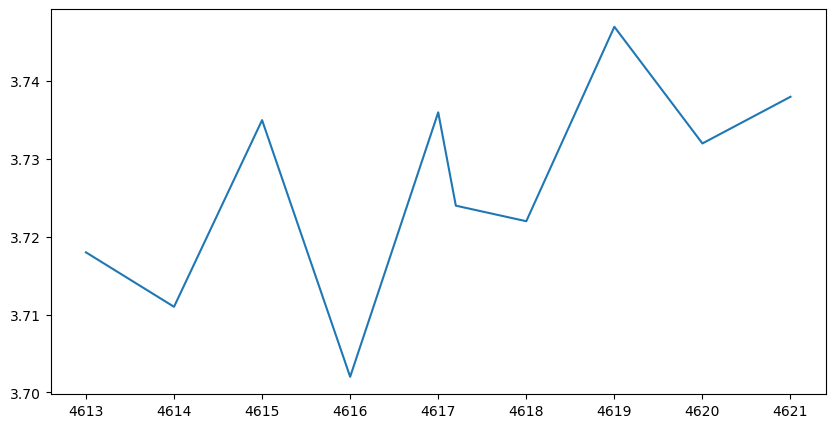

In [8]:
# Some datasets have extra data points in the cycle

df = hdf.get('/A/data_230509_ReCellML_A_Cell15_charac_30C')

df[df['Segment Description'].str.contains('Charge depleting cycle')]

time = df[df['Segment Description'].str.contains('Charge depleting cycle')]['Segment Time, S']

fig, ax = plt.subplots(figsize=(10, 5))
section = df[(df['Total Time, S'] >=369725.6) & (df['Total Time, S'] <= 369733.6)]
ax.plot(section['Segment Time, S'], section[col_voltage])
# ax.plot(range(len(time)), time / 60)

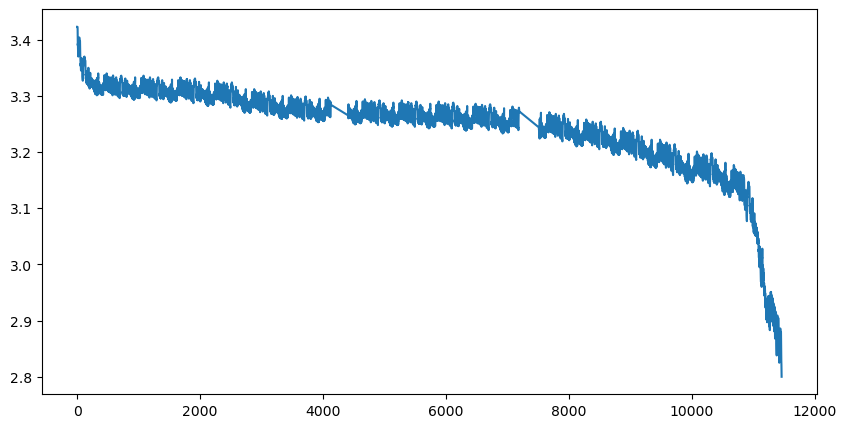

In [9]:
df = hdf.get('/D/data_240820_ReCellML_A123_cell27_charac_30oC')

df = df[df['Segment Description'].str.contains('Charge depleting cycle')]
df = retime(df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['Segment Time, S'], df[col_voltage])

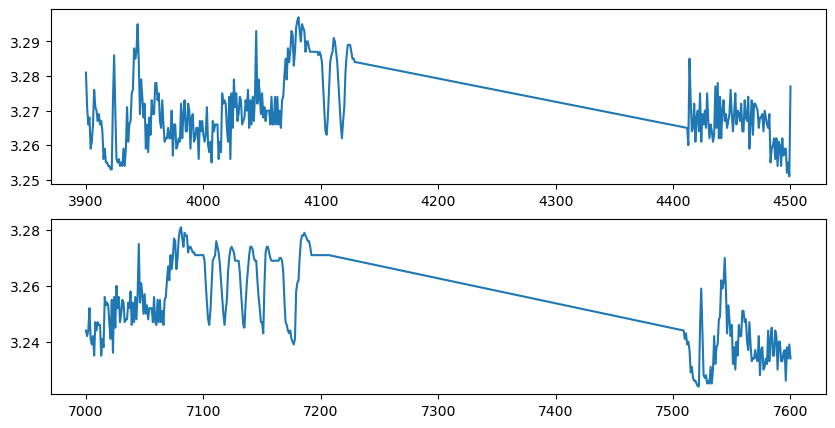

In [10]:
df = df[df['Segment Description'].str.contains('Charge depleting cycle')]
df = retime(df)

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
ax = ax.flatten()
df1 = df[df['Segment Time, S'].between(3900, 4500)]
df2 = df[df['Segment Time, S'].between(7000, 7600)]
ax[0].plot(df1['Segment Time, S'], df1[col_voltage])
ax[1].plot(df2['Segment Time, S'], df2[col_voltage])

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_12844\3056413589.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 4)
C:\Users\etenney\AppData\Local\Temp\1\ipykernel_12844\3056413589.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_first['cell_type'] = [id[0] for id in df_first['cell_id']]


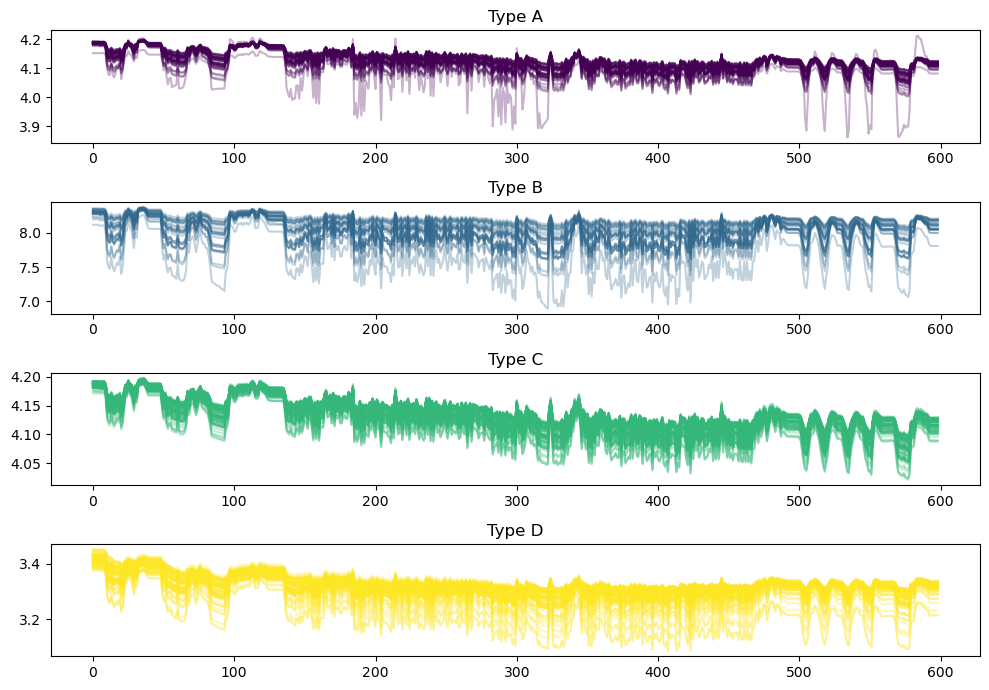

In [11]:
df = pd.read_csv('../../data/features_charge_depleting_cycles.csv')
df_first = df[df['soc_initial'] == 1.0]

cmap = cm.get_cmap('viridis', 4)

df_first['cell_type'] = [id[0] for id in df_first['cell_id']]

type_map = {
    'A': 0,
    'B': 1,
    'C': 2,
    'D': 3
}
fig, ax = plt.subplots(4, 1, figsize=(10, 7))
for i, row in df_first.iterrows():
    ax[type_map[row.cell_type]].plot(range(599), row.filter(regex='^voltage'), alpha=0.3, c = cmap(type_map[row.cell_type]))
# df_first
ax[0].set_title('Type A')
ax[1].set_title('Type B')
ax[2].set_title('Type C')
ax[3].set_title('Type D')

fig.tight_layout()

# ax = sns.relplot(data=df_first,x='Segment Time, T', y='', legend=False, alpha=0.3, col="cell_type", kind='line')

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_12844\3806608481.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 100)


Text(0.5, 1.0, 'Type A charge depleting cycle voltage profiles colored by SOC')

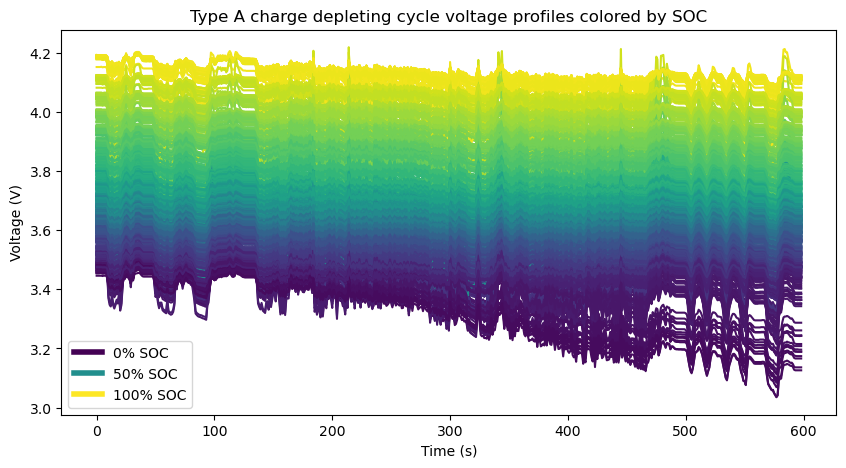

In [12]:
df_a = df[df['cell_id'].str.contains('A')]
cmap = cm.get_cmap('viridis', 100)
plt.figure(figsize=(10, 5))
for i, row in df_a.iterrows():
    plt.plot(range(599), row.filter(regex='^voltage'), alpha=1, c=cmap(row['soc_mean']))
    
plt.legend(handles=[plt.Line2D([0], [0], color=cmap(0), lw=4, label='0% SOC'),
                    plt.Line2D([0], [0], color=cmap(49), lw=4, label='50% SOC'),
                    plt.Line2D([0], [0], color=cmap(99), lw=4, label='100% SOC')])
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Type A charge depleting cycle voltage profiles colored by SOC')

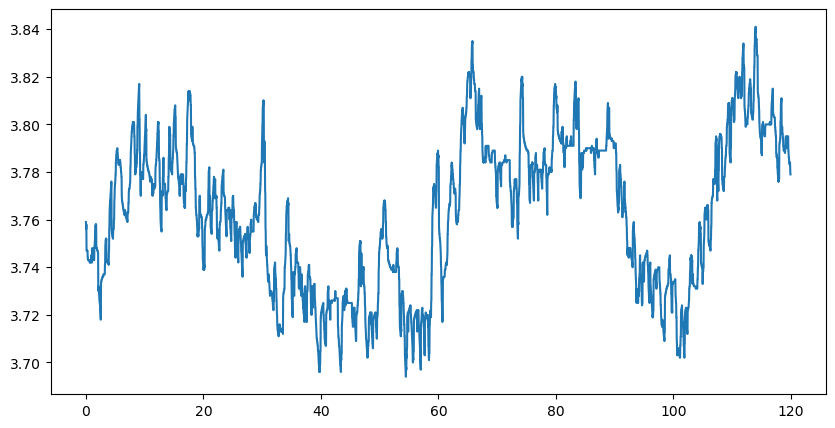

In [13]:
df = hdf.get('/A/data_230509_ReCellML_A_Cell15_charac_30C')
df = df[df['Segment Description'].str.contains('Charge sustaining cycle')]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['Segment Time, S'] / 60, df['Voltage, V'])

In [14]:
df = hdf.get('/D/data_240624_ReCellML_A123_Cell01_charac_30C')
df = df[df['Segment Description'].str.contains('Charge sustaining cycle')]
cell_id_prefix = 'A123'

if any(["Cell Voltage A1" in col for col in df.columns]):
    col_voltage = "Cell Voltage A1, V"
else:
    col_voltage = "Voltage, V"

is_cycle = [
    "Charge sustaining cycle" in seg_desc for seg_desc in df["Segment Description"]
]

df_seg = df[is_cycle]
# time = df_seg['Segment Time, S']
time = retime(df_seg)['Segment Time, S']

# mask_priorvoltage = [False] * len(is_cycle) # not sure this is needed
# len(is_cycle) - len(mask_priorvoltage)



if cell_id_prefix.startswith('A') or cell_id_prefix.startswith('B'):
    # voltage resolution is every 1 sec
    resolution = 1
else: 
    # voltage resolution is every 4 secs
    resolution = 4

# check for large gaps in time data, or extra data points
for i in range(len(time)-1):
    if time[i+1] - time[i] > resolution + 0.1:
        print(f"Large time gap found in charge sustaining cycle, check data quality")
        Warning("Large time gap found in charge sustaining cycle, check data quality")
    elif time[i+1] - time[i] < resolution - 0.1:
        print(f"Extra time data found in charge sustaining cycle, removing data")
        mask_keep = df_seg['Segment Time, S'] % resolution == 0
        df_seg = df_seg[mask_keep]
        df_seg = retime(df_seg)

time = df_seg['Segment Time, S']

for i, t in enumerate(time):
    if i == 0:
        columns_voltage = ["voltage_%5.1fs" % (t)]
        columns_current = ["current_%5.1fs" % (t)]
        columns_power = ["power_%5.1fs" % (t)]
    else:
        columns_voltage += ["voltage_%5.1fs" % (t)]
        columns_current += ["current_%5.1fs" % (t)]
        columns_power += ["power_%5.1fs" % (t)]

soc_mean = df_seg.SOC.to_numpy().mean()
soc_initial = df_seg.SOC.to_numpy()[0]
soc_final = df_seg.SOC.to_numpy()[-1]
temperature = np.mean(df_seg["Temperature A1, °C"].to_numpy())
voltage = df_seg[col_voltage].to_numpy()
current = df_seg["Current, A"].to_numpy()
power = df_seg["Power, W"].to_numpy()


out = np.hstack((temperature, soc_mean, soc_initial, soc_final, voltage, current, power))
columns = (["temperature", "soc_mean", "soc_initial", "soc_final"] + columns_voltage + columns_current + columns_power)
df_out = pd.Series(out, index=columns)

pd.DataFrame([df_out])

Large time gap found in charge sustaining cycle, check data quality
Large time gap found in charge sustaining cycle, check data quality
Large time gap found in charge sustaining cycle, check data quality
Large time gap found in charge sustaining cycle, check data quality
Large time gap found in charge sustaining cycle, check data quality
Large time gap found in charge sustaining cycle, check data quality
Large time gap found in charge sustaining cycle, check data quality
Large time gap found in charge sustaining cycle, check data quality
Large time gap found in charge sustaining cycle, check data quality
Large time gap found in charge sustaining cycle, check data quality
Large time gap found in charge sustaining cycle, check data quality
Large time gap found in charge sustaining cycle, check data quality
Large time gap found in charge sustaining cycle, check data quality
Large time gap found in charge sustaining cycle, check data quality
Large time gap found in charge sustaining cycle,

,temperature,soc_mean,soc_initial,soc_final,voltage_ 0.0s,voltage_ 4.0s,voltage_ 8.0s,voltage_ 12.0s,voltage_ 16.0s,voltage_ 20.0s,...,power_7160.0s,power_7164.0s,power_7168.0s,power_7172.0s,power_7176.0s,power_7180.0s,power_7184.0s,power_7188.0s,power_7192.0s,power_7196.0s
0,29.827222,-0.305898,-0.285465,-0.331158,3.302,3.303,3.297,3.297,3.297,3.295,...,-0.8,0.0,0.0,0.0,-1.1,-1.5,-1.7,-1.7,-1.6,-2.3


In [15]:
df = hdf.get('/D/data_240626_ReCellML_A123_Cell04_charac_30C')

df = df[df['Segment Description'].str.contains('Rate test C/2 cycle charge CC')]
df
# fig, ax = plt.subplots(figsize=(10, 5))
# ax.plot(df['Segment Time, S'] / 60, df['Voltage, V'])

,"Total Time, S",Cycle,Loop Counter #1,Loop Counter #2,Loop Counter #3,Step,"Step Time, S","Current, A","Voltage, V","Power, W","Amp-Hours, AH","Watt-Hours, WH","Temperature A1, °C",Mode,Real Time,Data Acquisition Flag,Segment Description,"Segment Time, S",SOC
296185,403634.8,1,1,1,1,2598,0.1,1.15,2.932,3.3,0.00,0.00,30.0,CHRG,7/1/2024 10:22:54 AM,,Rate test C/2 cycle charge CC,0.0,0.000000
296186,403635.0,1,1,1,1,2598,0.3,1.15,2.933,3.3,0.00,0.00,30.0,CHRG,7/1/2024 10:22:54 AM,,Rate test C/2 cycle charge CC,0.2,0.000027
296187,403635.1,1,1,1,1,2598,0.4,1.15,2.934,3.3,0.00,0.00,30.0,CHRG,7/1/2024 10:22:54 AM,,Rate test C/2 cycle charge CC,0.3,0.000040
296188,403635.4,1,1,1,1,2598,0.7,1.15,2.935,3.3,0.00,0.00,30.0,CHRG,7/1/2024 10:22:55 AM,,Rate test C/2 cycle charge CC,0.6,0.000080
296189,403635.7,1,1,1,1,2598,1.0,1.15,2.936,3.3,0.00,0.00,30.0,CHRG,7/1/2024 10:22:55 AM,,Rate test C/2 cycle charge CC,0.9,0.000121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301549,410920.9,1,1,1,1,2598,7286.2,1.15,3.497,4.0,2.32,7.64,30.5,CHRG,7/1/2024 12:24:20 PM,,Rate test C/2 cycle charge CC,7286.1,0.977056
301550,410922.6,1,1,1,1,2598,7287.9,1.15,3.498,4.0,2.32,7.64,30.5,CHRG,7/1/2024 12:24:22 PM,,Rate test C/2 cycle charge CC,7287.8,0.977284
301551,410924.2,1,1,1,1,2598,7289.5,1.15,3.499,4.0,2.32,7.64,30.5,CHRG,7/1/2024 12:24:24 PM,,Rate test C/2 cycle charge CC,7289.4,0.977499
301552,410924.7,1,1,1,1,2598,7290.0,1.15,3.499,4.0,2.32,7.64,30.5,CHRG,7/1/2024 12:24:24 PM,,Rate test C/2 cycle charge CC,7289.9,0.977566


In [16]:
df = hdf.get('/A/data_230525_ReCellML_A_Cell15_charac_15C')

df = df[df['Segment Description'].str.contains('Rate test C/2 cycle charge CC')]
df

,"Total Time, S",Cycle,Loop Counter #1,Loop Counter #2,Loop Counter #3,Step,"Step Time, S","Current, A","Voltage, V","Power, W","Amp-Hours, AH","Watt-Hours, WH","Temperature A1, °C",Mode,Real Time,Data Acquisition Flag,Segment Description,"Segment Time, S",SOC
284769,384455.2,1,1,1,1,2598,0.1,31.99,3.178,101.6,0.00,0.00,16.0,CHRG,12/31/1999 4:59:59 PM,,Rate test C/2 cycle charge CC,0.0,0.000000
284770,384455.3,1,1,1,1,2598,0.2,32.00,3.188,102.0,0.00,0.00,16.0,CHRG,12/31/1999 4:59:59 PM,,Rate test C/2 cycle charge CC,0.1,0.000014
284771,384455.4,1,1,1,1,2598,0.3,32.00,3.194,102.0,0.00,0.00,16.0,CHRG,12/31/1999 4:59:59 PM,,Rate test C/2 cycle charge CC,0.2,0.000028
284772,384455.5,1,1,1,1,2598,0.4,32.00,3.198,102.2,0.00,0.01,16.0,CHRG,12/31/1999 4:59:59 PM,,Rate test C/2 cycle charge CC,0.3,0.000043
284773,384455.6,1,1,1,1,2598,0.5,32.00,3.201,102.4,0.00,0.01,16.0,CHRG,12/31/1999 4:59:59 PM,,Rate test C/2 cycle charge CC,0.4,0.000057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289545,391307.0,1,1,1,1,2598,6851.9,32.00,4.198,134.2,60.90,230.14,16.5,CHRG,12/31/1999 4:59:59 PM,,Rate test C/2 cycle charge CC,6851.8,0.975532
289546,391311.3,1,1,1,1,2598,6856.2,32.00,4.199,134.2,60.94,230.30,16.5,CHRG,12/31/1999 4:59:59 PM,,Rate test C/2 cycle charge CC,6856.1,0.976144
289547,391311.5,1,1,1,1,2598,6856.4,32.00,4.198,134.2,60.94,230.30,16.5,CHRG,12/31/1999 4:59:59 PM,,Rate test C/2 cycle charge CC,6856.3,0.976173
289548,391311.6,1,1,1,1,2598,6856.5,32.00,4.199,134.2,60.94,230.31,16.5,CHRG,12/31/1999 4:59:59 PM,,Rate test C/2 cycle charge CC,6856.4,0.976187


Get Charge Cycles:

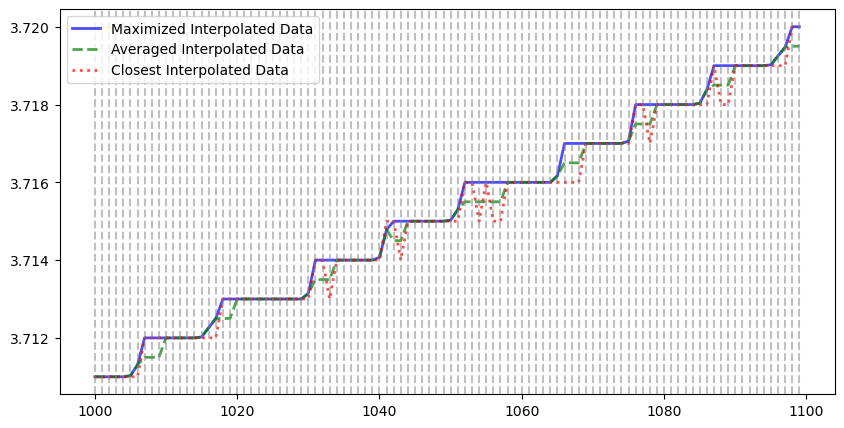

In [ ]:
df = hdf.get('/A/data_230525_ReCellML_A_Cell15_charac_15C')

key = "PsRP 1 1C diagnostic cycle charge"
cell_id_prefix = 'A_'
cell_id_num = '15'

# For a measurement, return collated data from the charge cycle
if any(["Cell Voltage A1" in col for col in df.columns]):
    col_voltage = "Cell Voltage A1, V"
else:
    col_voltage = "Voltage, V"

is_cycle = [
    key in seg_desc for seg_desc in df["Segment Description"]
]

df_seg = retime(df[is_cycle])
# time = df_seg['Segment Time, S']
time = retime(df_seg)['Segment Time, S']


columns = [
    "Voltage_",
    "Current_",
    "Power_",
    "SOC_",
    "Segment_Time_S_",
]
if df_seg.iloc[0]['Temperature A1, °C'] < 25:
    temp_category = '15C'
elif (df_seg.iloc[0]['Temperature A1, °C'] > 25) and (df_seg.iloc[0]['Temperature A1, °C'] <= 38):
    temp_category = '30C'
elif df_seg.iloc[0]['Temperature A1, °C'] > 38:
    temp_category = '45C'

for i, col in enumerate(columns):
    columns[i] = col + cell_id_prefix + "Cell" + cell_id_num +"_" + temp_category




# for i, t in enumerate(time):
#     if i == 0:
#         columns_soc = ["soc_%5.1fs" % (t)]
#         columns_voltage = ["voltage_%5.1fs" % (t)]
#         columns_current = ["current_%5.1fs" % (t)]
#         columns_power = ["power_%5.1fs" % (t)]
#     else:
#         columns_soc += ["soc_%5.1fs" % (t)]
#         columns_voltage += ["voltage_%5.1fs" % (t)]
#         columns_current += ["current_%5.1fs" % (t)]
#         columns_power += ["power_%5.1fs" % (t)]

# soc_mean = df_seg.SOC.to_numpy().mean()
# soc_initial = df_seg.SOC
# soc_final = df_seg.SOC.to_numpy()[-1]
soc = df_seg.SOC.to_numpy()
# temperature = np.mean(df_seg["Temperature A1, °C"].to_numpy())
voltage = df_seg[col_voltage].to_numpy()
current = df_seg["Current, A"].to_numpy()
power = df_seg["Power, W"].to_numpy()

out = np.vstack((soc, voltage, current, power, time))

def get_2_closest_cols(df_seg, target_time):
    times = df_seg['Segment Time, S'].to_numpy()
    diffs = np.abs(times - target_time)
    idx_sorted = np.argsort(diffs)
    return (df_seg.iloc[idx_sorted[0]], df_seg.iloc[idx_sorted[1]])

#interpolate the data at 1 second intervals
for i in range(time[len(time)-1].round().astype(int)):
    
    if i == 0:
        soc_interp = [soc[0]]
        voltage_interp = [voltage[0]]
        current_interp = [current[0]]
        power_interp = [power[0]]
        time_interp = [i]
        soc_interp_av = [soc[0]]
        voltage_interp_av = [voltage[0]]
        current_interp_av = [current[0]]
        power_interp_av = [power[0]]
        soc_interp_closest = [soc[0]]   
        voltage_interp_closest = [voltage[0]]
        current_interp_closest = [current[0]]
        power_interp_closest = [power[0]]
        continue

    time_interp += [i]

    # if the two closest points are already at 1 second intervals, just take the closest value
    seg_1, seg_2 = get_2_closest_cols(df_seg, i)
    time_1 = seg_1['Segment Time, S']
    time_2 = seg_2['Segment Time, S']

    #save the closer of the two points
    if time_2 < time_1:
        soc_interp_closest += [seg_2['SOC']]
        voltage_interp_closest += [seg_2[col_voltage]]
        current_interp_closest += [seg_2['Current, A']]
        power_interp_closest += [seg_2['Power, W']]
    else:
        soc_interp_closest += [seg_1['SOC']]
        voltage_interp_closest += [seg_1[col_voltage]]
        current_interp_closest += [seg_1['Current, A']]
        power_interp_closest += [seg_1['Power, W']]

    if (time_2 - time_1) == 1:
        if time_2 < time_1: #time 2 is the closest point
            soc_interp += [seg_2['SOC']]
            voltage_interp += [seg_2[col_voltage]] 
            current_interp += [seg_2['Current, A']]
            power_interp += [seg_2['Power, W']]
            soc_interp_av += [seg_2['SOC']]
            voltage_interp_av += [seg_2[col_voltage]]
            current_interp_av += [seg_2['Current, A']]
            power_interp_av += [seg_2['Power, W']]
        else:
            soc_interp += [seg_1['SOC']]
            voltage_interp += [seg_1[col_voltage]] 
            current_interp += [seg_1['Current, A']]
            power_interp += [seg_1['Power, W']]
            soc_interp_av += [seg_1['SOC']]
            voltage_interp_av += [seg_1[col_voltage]]
            current_interp_av += [seg_1['Current, A']]
            power_interp_av += [seg_1['Power, W']]
        continue

    #if the two points are within 0.3 seconds of each other, take the highest
    if (time_2 - time_1) < 0.3: 
        soc_interp += [max(seg_1['SOC'], seg_2['SOC'])]
        voltage_interp += [max(seg_1[col_voltage], seg_2[col_voltage])]
        current_interp += [max(seg_1['Current, A'], seg_2['Current, A'])]
        power_interp += [max(seg_1['Power, W'], seg_2['Power, W'])]

        soc_interp_av += [(seg_1['SOC'] + seg_2['SOC']) / 2]
        voltage_interp_av += [(seg_1[col_voltage] + seg_2[col_voltage]) / 2]
        current_interp_av += [(seg_1['Current, A'] + seg_2['Current, A']) / 2]
        power_interp_av += [(seg_1['Power, W'] + seg_2['Power, W']) / 2]
        continue

    #finally, if the two closest points are not at 1 second intervals, interpolate with two closest points
    # soc_interp += [np.interp(i, (time_1, time_2), (seg_1['SOC'], seg_2['SOC']))]
    # voltage_interp += [np.interp(i, (time_1, time_2), (seg_1[col_voltage], seg_2[col_voltage]))]
    # current_interp += [np.interp(i, (time_1, time_2), (seg_1['Current, A'], seg_2['Current, A']))]
    # power_interp += [np.interp(i, (time_1, time_2), (seg_1['Power, W'], seg_2['Power, W']))]

    soc_interp += [np.interp(i, time, soc)]
    voltage_interp += [np.interp(i, time, voltage)]
    current_interp += [np.interp(i, time, current)]
    power_interp += [np.interp(i, time, power)]

    soc_interp_av += [np.interp(i, time, soc)]
    voltage_interp_av += [np.interp(i, time, voltage)]
    current_interp_av += [np.interp(i, time, current)]
    power_interp_av += [np.interp(i, time, power)]


out_interp = np.vstack((soc_interp, voltage_interp, current_interp, power_interp, time_interp))
out_interp_av = np.vstack((soc_interp_av, voltage_interp_av, current_interp_av, power_interp_av, time_interp))
out_interp_closest = np.vstack((soc_interp_closest, voltage_interp_closest, current_interp_closest, power_interp_closest, time_interp))
# out
# columns = (["temperature"] + columns_soc + columns_voltage + columns_current + columns_power)
df_out = pd.DataFrame(out_interp, index=columns)
# df_out

df_out_av = pd.DataFrame(out_interp_av, index=columns)  
df_out_closest = pd.DataFrame(out_interp_closest, index=columns)

offset = 1000
length = 100
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_out.iloc[-1][offset:offset+length], df_out.iloc[1][offset:offset+length], label='Maximized Interpolated Data', color='blue', alpha=0.7, linewidth=2)
ax.plot(df_out_av.iloc[-1][offset:offset+length], df_out_av.iloc[1][offset:offset+length], label='Averaged Interpolated Data', color='green', alpha=0.7, linewidth=2, linestyle='--')
ax.plot(df_out_closest.iloc[-1][offset:offset+length], df_out_closest.iloc[1][offset:offset+length], label='Closest Interpolated Data', color='red', alpha=0.7, linewidth=2, linestyle=':')
for point in df_out.iloc[-1][offset:offset+length]:
    ax.axvline(point, color='gray', linestyle='--', alpha=0.5) 

#write dfs out to csv
df_out.to_csv('df_out.csv')
df_out_av.to_csv('df_out_av.csv')
df_out_closest.to_csv('df_out_closest.csv')

plt.legend()


In [18]:
df = pd.read_csv('../../data/features_partial_charge_rate_test_C2_charge_cc.csv', index_col="Unnamed: 0")

voltage_rows = df[df.index.str.contains('Voltage_A')]
time_rows = df[df.index.str.contains('Segment_Time_S_A')]

for i, v_row, t_row in zip(range(len(voltage_rows)), voltage_rows.iterrows(), time_rows.iterrows()):
    time = t_row[1].filter(regex='[0-9]').to_numpy()
    data = v_row[1].filter(regex='[0-9]').to_numpy()
    plt.plot(time, data, label=v_row[0])

AttributeError: Can only use .str accessor with string values!

Text(0, 0.5, 'Voltage (V)')

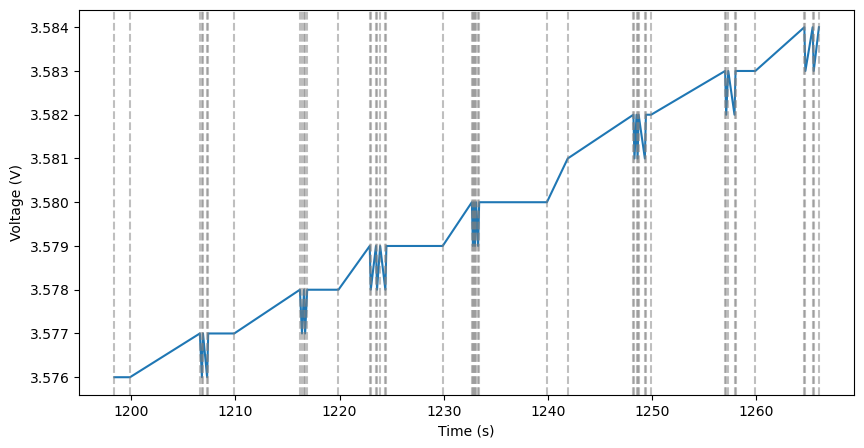

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

offset = 1000
length = 50
_time = time_rows.iloc[0].iloc[offset:offset+length]
_data = voltage_rows.iloc[0].iloc[offset:offset+length]
ax.plot(_time, _data)   
for point in _time:
    ax.axvline(point, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (V)')

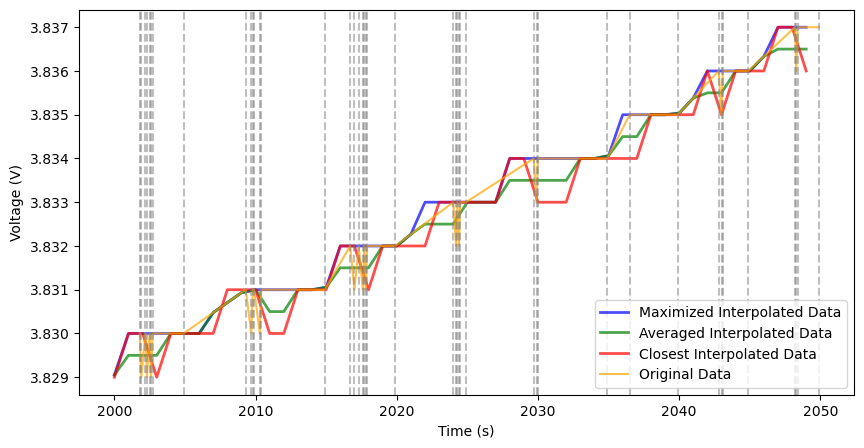

In [ ]:
df = pd.HDFStore('../../data/data_raw.h5', mode='r')
df = df.get('/A/data_230525_ReCellML_A_Cell15_charac_15C')

df = df[df['Segment Description'].str.contains('PsRP 1 1C diagnostic cycle charge')]
df = retime(df)

offset = 2000
length = 50
df = df[df['Segment Time, S'].between(offset, offset+length)]

_time = df['Segment Time, S'].values
_data = df['Voltage, V'].values

#compare the interpolated data to the original data
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_out.iloc[-1][offset:offset+length], df_out.iloc[1][offset:offset+length], label='Maximized Interpolated Data', color='blue', alpha=0.7, linewidth=2)
ax.plot(df_out_av.iloc[-1][offset:offset+length], df_out_av.iloc[1][offset:offset+length], label='Averaged Interpolated Data', color='green', alpha=0.7, linewidth=2)
ax.plot(df_out_closest.iloc[-1][offset:offset+length], df_out_closest.iloc[1][offset:offset+length], label='Closest Interpolated Data', color='red', alpha=0.7, linewidth=2)
ax.plot(_time, _data, label='Original Data', color='orange', alpha=0.7)
for point in _time:
    ax.axvline(point, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (V)')
ax.legend()

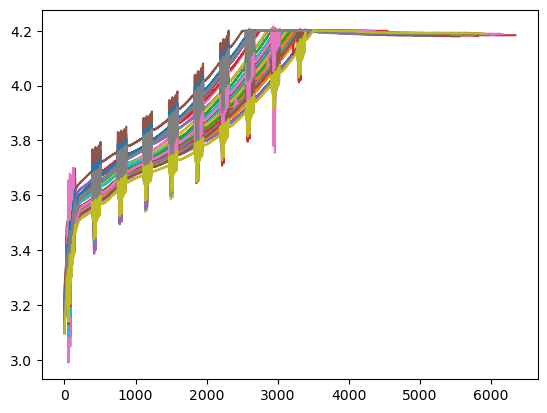

In [ ]:
df = pd.read_csv('../../data/features_partial_charge_psrp_1_1C_charge.csv', index_col="Unnamed: 0")

voltage_rows = df[df.index.str.contains('Voltage_A')]
time_rows = df[df.index.str.contains('Segment_Time_S_A')]

for i, v_row, t_row in zip(range(len(voltage_rows)), voltage_rows.iterrows(), time_rows.iterrows()):
    time = t_row[1].filter(regex='[0-9]').to_numpy()
    data = v_row[1].filter(regex='[0-9]').to_numpy()
    plt.plot(time, data, label=v_row[0])

Text(0, 0.5, 'Voltage (V)')

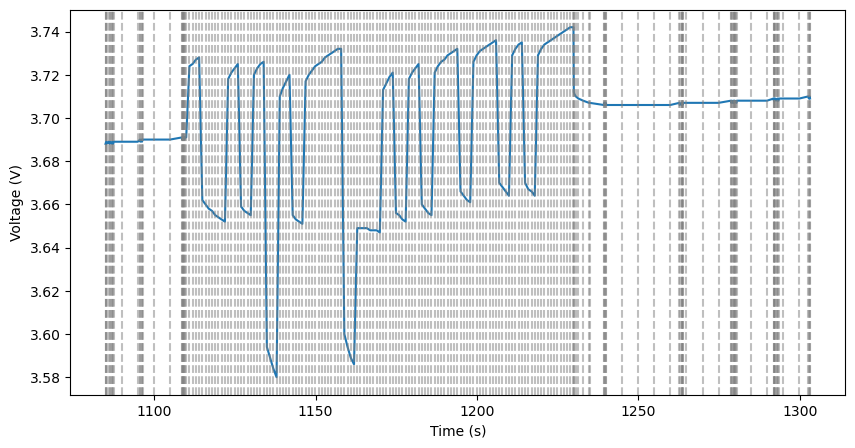

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

offset = 1050
_time = time_rows.iloc[0].iloc[offset:offset+200]
_data = voltage_rows.iloc[0].iloc[offset:offset+200]
ax.plot(_time, _data)   
for point in _time:
    ax.axvline(point, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (V)')

In [ ]:
df = pd.HDFStore('../../data/data_raw.h5', mode='r')
df = df.get('/A/data_230509_ReCellML_A_Cell15_charac_30C')
df = df[df['Segment Description'].str.contains('PsRP 1 1C diagnostic cycle charge')]

#print entire data frame
print(df.to_string())

        Total Time, S  Cycle  Loop Counter #1  Loop Counter #2  Loop Counter #3  Step  Step Time, S  Current, A  Voltage, V  Power, W  Amp-Hours, AH  Watt-Hours, WH  Temperature A1, °C  Mode              Real Time Data Acquisition Flag                            Segment Description  Segment Time, S       SOC
334182       468712.7      1                1                1                1  2716           0.1       61.83       3.119     192.7           0.00            0.00                30.0  CHRG  5/14/2023 11:14:55 PM                        PsRP 1 1C diagnostic cycle charge 10 SOC CC 1              0.0  0.000000
334183       468712.8      1                1                1                1  2716           0.2       64.00       3.131     200.3           0.00            0.01                30.0  CHRG  5/14/2023 11:14:55 PM                        PsRP 1 1C diagnostic cycle charge 10 SOC CC 1              0.1  0.000027
334184       468712.9      1                1                1        

# Testing/Training Randomization
Get Randomized sections of each partial charge type.

Found segment starting at 1409 seconds
Found segment starting at 1818 seconds
Found segment starting at 1918 seconds
Found segment starting at 1042 seconds
Found segment starting at 680 seconds
Found segment starting at 982 seconds
Found segment starting at 1122 seconds
Found segment starting at 2999 seconds
Found segment starting at 1180 seconds


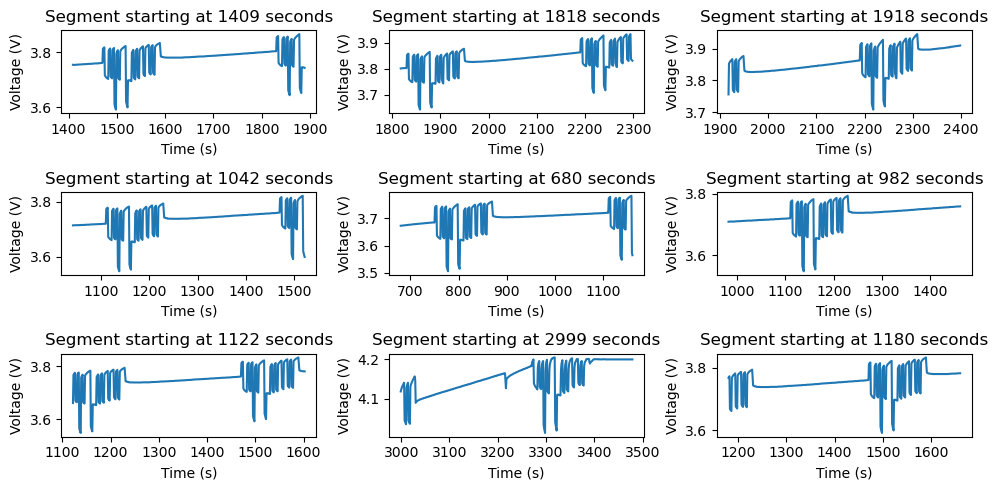

In [ ]:
import random
segment_length = 480 # 8 minutes in secs
df = df_out_av.T
# print(df)

fig, ax = plt.subplots(3, 3, figsize=(10, 5))
ax = ax.flatten()
for i in range(9):
    start_time = random.randint(0, 3600 - segment_length)

    df_segment = df[df[columns[4]].between(start_time, start_time + segment_length)].T
    # print(len(df_segment.columns), segment_length+1)
    if len(df_segment.columns) == segment_length+1 :
        print(f"Found segment starting at {start_time} seconds")
        ax[i].plot(df_segment.iloc[-1], df_segment.iloc[1])

        ax[i].set_title(f'Segment starting at {start_time} seconds')
        ax[i].set_xlabel('Time (s)')
        ax[i].set_ylabel('Voltage (V)')
    else:
        print(f"Segment starting at {start_time} seconds is incomplete, only {len(df_segment.columns)} data points")

fig.tight_layout()
    

In [ ]:
df = hdf.get('/A/data_230525_ReCellML_A_Cell15_charac_15C')

if any(["Cell Voltage A1" in col for col in df.columns]):
    col_voltage = "Cell Voltage A1, V"
else:
    col_voltage = "Voltage, V"

is_cycle = [
    key in seg_desc for seg_desc in df["Segment Description"]
]

df_seg = retime(df[is_cycle])
# time = df_seg['Segment Time, S']
time = retime(df_seg)['Segment Time, S']
soc = df_seg.SOC.to_numpy()
# temperature = np.mean(df_seg["Temperature A1, °C"].to_numpy())
voltage = df_seg[col_voltage].to_numpy()
current = df_seg["Current, A"].to_numpy()
power = df_seg["Power, W"].to_numpy()

out = np.vstack((soc, voltage, current, power, time))

def get_2_closest_cols(df_seg, target_time):
    times = df_seg['Segment Time, S'].to_numpy()
    diffs = np.abs(times - target_time)
    idx_sorted = np.argsort(diffs)
    return (df_seg.iloc[idx_sorted[0]], df_seg.iloc[idx_sorted[1]])

#interpolate the data at 1 second intervals
for i in range(time[len(time)-1].round().astype(int)):
    
    if i == 0:
        soc_interp = [soc[0]]
        voltage_interp = [voltage[0]]
        current_interp = [current[0]]
        power_interp = [power[0]]
        time_interp = [i]
        continue

    time_interp += [i]

    # if the two closest points are already at 1 second intervals, just take the closest value
    seg_1, seg_2 = get_2_closest_cols(df_seg, i)
    time_1 = seg_1['Segment Time, S']
    time_2 = seg_2['Segment Time, S']
    if (time_2 - time_1) == 1:
        if time_2 < time_1: #time 2 is the closest point
            soc_interp += [seg_2['SOC']]
            voltage_interp += [seg_2[col_voltage]] 
            current_interp += [seg_2['Current, A']]
            power_interp += [seg_2['Power, W']]
        else:
            soc_interp += [seg_1['SOC']]
            voltage_interp += [seg_1[col_voltage]] 
            current_interp += [seg_1['Current, A']]
            power_interp += [seg_1['Power, W']]
        continue

    #if the two points are within 0.3 seconds of each other, take the average
    if (time_2 - time_1) < 0.3: 
        soc_interp += [(seg_1['SOC'] + seg_2['SOC']) / 2]
        voltage_interp += [(seg_1[col_voltage] + seg_2[col_voltage]) / 2]
        current_interp += [(seg_1['Current, A'] + seg_2['Current, A']) / 2]
        power_interp += [(seg_1['Power, W'] + seg_2['Power, W']) / 2]
        continue
    #finally, if the two closest points are not at 1 second intervals, interpolate
    soc_interp += [np.interp(i, time, soc)]
    voltage_interp += [np.interp(i, time, voltage)]
    current_interp += [np.interp(i, time, current)]
    power_interp += [np.interp(i, time, power)]


#get 100 random samples of segment_length seconds from the charge cycle
for i in range(100):
    start_time = np.random.randint(0, len(time_interp) - segment_length)

    voltage_sample = voltage_interp[start_time:start_time + segment_length]
    current_sample = current_interp[start_time:start_time + segment_length]
    power_sample = power_interp[start_time:start_time + segment_length]
    soc_mean = np.mean(soc_interp[start_time:start_time + segment_length])
    soc_initial = soc_interp[start_time]
    soc_final = soc_interp[start_time + segment_length - 1]
    temperature_sample = np.mean(df_seg["Temperature A1, °C"].to_numpy())

    out = np.hstack((temperature_sample, soc_mean, soc_initial, soc_final, voltage_sample, current_sample, power_sample))
    columns = (["temperature", "soc_mean", "soc_initial", "soc_final"] +
                ["voltage_%3.1fs" % (j) for j in range(segment_length)] +
                ["current_%3.1fs" % (j) for j in range(segment_length)] +
                ["power_%3.1fs" % (j) for j in range(segment_length)])

    df_out_sample = pd.Series(out, index=columns)
    if i == 0:
        df_out = pd.DataFrame([df_out_sample])
    elif len(df_out_sample) == segment_length * 3 + 4: # make sure the sample is the correct length
        df_out = pd.concat([df_out, pd.DataFrame([df_out_sample])], ignore_index=True)
    else:
        print(f"sample {i} is the wrong length, skipping")

df_out

,temperature,soc_mean,soc_initial,soc_final,voltage_0.0s,voltage_1.0s,voltage_2.0s,voltage_3.0s,voltage_4.0s,voltage_5.0s,...,power_470.0s,power_471.0s,power_472.0s,power_473.0s,power_474.0s,power_475.0s,power_476.0s,power_477.0s,power_478.0s,power_479.0s
0,17.835831,0.076663,0.010891,0.144035,3.44700,3.457000,3.465000,3.472000,3.329000,3.3220,...,233.326316,233.221053,233.200,233.200,233.200,233.200,233.200,233.200,233.200,233.200
1,17.835831,0.999996,1.000000,0.999992,4.19463,4.194530,4.194500,4.194500,4.194500,4.1945,...,0.000000,0.000000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,17.835831,0.896807,0.836703,0.946784,4.09350,4.094500,4.095769,4.096000,4.096500,4.0975,...,151.900000,151.900000,150.478,150.018,149.650,149.650,149.650,148.178,147.718,147.350
3,17.835831,0.907509,0.849917,0.953574,4.11500,4.115478,4.115500,4.116348,4.116783,4.1170,...,130.420000,130.100000,130.100,130.100,128.834,128.454,128.150,128.150,128.150,126.948
4,17.835831,0.772696,0.707192,0.839758,3.99500,3.999000,4.002000,3.907000,3.904000,3.9020,...,262.000000,262.000000,262.000,262.100,262.200,262.200,262.200,262.300,262.350,262.400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,17.835831,0.999996,1.000000,0.999993,4.19600,4.196000,4.196000,4.196000,4.196000,4.1960,...,0.000000,0.000000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
96,17.835831,0.998684,0.995048,0.999998,4.20000,4.200000,4.200000,4.200000,4.200000,4.2000,...,0.000000,0.000000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
97,17.835831,0.950585,0.909025,0.976770,4.11000,4.109000,4.109000,4.172000,4.188000,4.1940,...,65.900000,65.218000,64.958,64.750,64.750,64.750,63.946,63.726,63.550,63.550
98,17.835831,0.999986,0.999989,0.999981,4.18700,4.187000,4.187000,4.187000,4.187000,4.1870,...,0.000000,0.000000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


Charge depleting cycle: for each 10 min segment, last 2 mins are testing. Split first 8 minutes into 5 random 120 s windows

removed extra data in segment starting at 4193 seconds
removed extra data in segment starting at 4792 seconds
removed extra data in segment starting at 5391 seconds
number 1
[4.139 4.143 4.144 4.137 4.131 4.139 4.138 4.137 4.126 4.132 4.131 4.129
 4.127 4.126 4.126 4.126 4.126 4.126 4.126 4.126 4.126 4.125 4.122 4.11
 4.099 4.09  4.088 4.097 4.112 4.125 4.127 4.128 4.135 4.132 4.127 4.121
 4.111 4.102 4.093 4.087 4.096 4.103 4.119 4.128 4.132 4.131 4.13  4.126
 4.122 4.123 4.122 4.122 4.114 4.104 4.095 4.087 4.085 4.1   4.112 4.119
 4.126 4.131 4.13  4.128 4.123 4.121 4.121 4.109 4.099 4.095 4.087 4.088
 4.083 4.111 4.129 4.131 4.13  4.126 4.123 4.12  4.119 4.119 4.119 4.119
 4.12  4.12  4.12  4.12  4.119 4.112 4.097 4.085 4.084 4.082 4.081 4.083
 4.079 4.078 4.077 4.081 4.108 4.111 4.112 4.125 4.134 4.134 4.134 4.134
 4.132 4.13  4.128 4.128 4.125 4.12  4.119 4.119 4.119 4.119 4.119 4.119]
done


Text(0.5, 1.0, 'Type A charge depleting cycle voltage profiles colored by SOC')

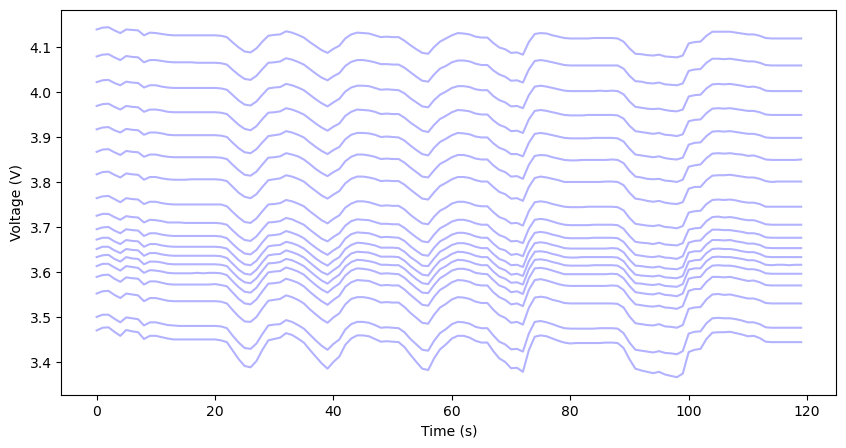

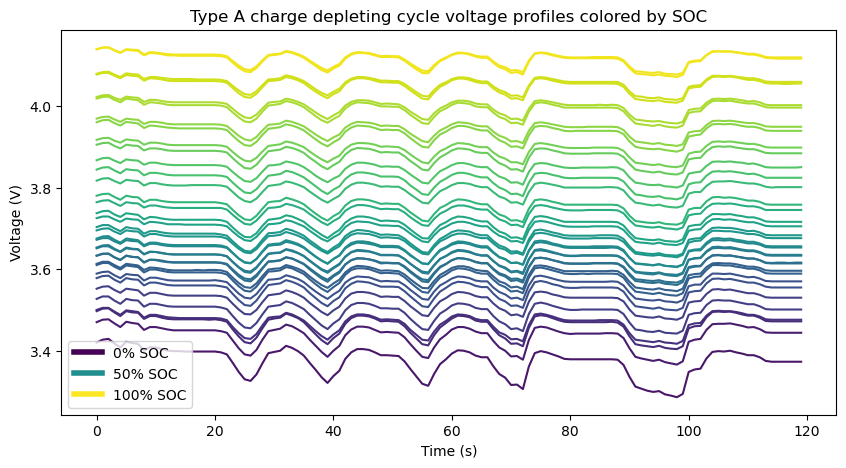

In [ ]:
df = hdf.get('/A/data_230509_ReCellML_A_Cell15_charac_30C')

# For a measurement, return collated data from the charge-depleting cycle
if any(["Cell Voltage A1" in col for col in df.columns]):
    col_voltage = "Cell Voltage A1, V"
else:
    col_voltage = "Voltage, V"

is_cycle = [
    "Charge depleting cycle" in seg_desc for seg_desc in df["Segment Description"]
]

#split the repeating charge depleting cycles into individual 10 min cycles
dfs = get_10_min_segments(df[is_cycle])
time = dfs[0]['Segment Time, S']

# mask_priorvoltage = [False] * len(is_cycle) # not sure this is needed
# len(is_cycle) - len(mask_priorvoltage)

df_testing = []
df_training = []

for df in dfs:
    # save last 120 seconds of data separately
    df_last_120s = df[-120:]
    df.drop(df.index[-120:], inplace=True)
    df.reset_index(drop=True, inplace=True)

    df_last_120s.reset_index(drop=True, inplace=True)
    df_testing += [df_last_120s]

    for i in range(5):
        start_time = np.random.randint(0, len(df) - 120) # random start time for 8 min segment
        df_segment = df[start_time:start_time + 120]
        df_segment.reset_index(drop=True, inplace=True)
        df_training += [df_segment]
    
time = df_testing[0]['Segment Time, S'] - 479 # reset time to start from 0

for i, t in enumerate(time):
    if i == 0:
        columns_soc = ["soc_%5.1fs" % (t)]
        columns_voltage = ["voltage_%5.1fs" % (t)]
        columns_current = ["current_%5.1fs" % (t)]
        columns_power = ["power_%5.1fs" % (t)]
    else:
        columns_soc += ["soc_%5.1fs" % (t)]
        columns_voltage += ["voltage_%5.1fs" % (t)]
        columns_current += ["current_%5.1fs" % (t)]
        columns_power += ["power_%5.1fs" % (t)]

for i, df_seg in enumerate(df_testing):
    if i == 0:
        soc_mean = df_seg.SOC.to_numpy().mean()
        soc_initial = df_seg.SOC.to_numpy()[0]
        soc_final = df_seg.SOC.to_numpy()[-1]
        temperature = np.mean(df_seg["Temperature A1, °C"].to_numpy())
        voltage = df_seg[col_voltage].to_numpy()
        current = df_seg["Current, A"].to_numpy()
        power = df_seg["Power, W"].to_numpy()
        type = [['testing']]
    else:
        soc_mean = np.vstack((soc_mean, df_seg.SOC.to_numpy().mean()))
        soc_initial = np.vstack((soc_initial, df_seg.SOC.to_numpy()[0]))
        soc_final = np.vstack((soc_final, df_seg.SOC.to_numpy()[-1]))
        temperature = np.vstack((temperature, np.mean(df_seg["Temperature A1, °C"].to_numpy())))
        voltage = np.vstack((voltage, df_seg[col_voltage].to_numpy()))
        current = np.vstack((current, df_seg["Current, A"].to_numpy()))
        power = np.vstack((power, df_seg["Power, W"].to_numpy()))
        type += [['testing']]

for i, df_seg in enumerate(df_training):
    soc_mean = np.vstack((soc_mean, df_seg.SOC.to_numpy().mean()))
    soc_initial = np.vstack((soc_initial, df_seg.SOC.to_numpy()[0]))
    soc_final = np.vstack((soc_final, df_seg.SOC.to_numpy()[-1]))
    temperature = np.vstack((temperature, np.mean(df_seg["Temperature A1, °C"].to_numpy())))
    voltage = np.vstack((voltage, df_seg[col_voltage].to_numpy()))
    current = np.vstack((current, df_seg["Current, A"].to_numpy()))
    power = np.vstack((power, df_seg["Power, W"].to_numpy()))
    type += [['training']]

out = np.hstack((temperature, soc_mean, soc_initial, soc_final, type, voltage, current, power))
columns = (["temperature", "soc_mean", "soc_initial", "soc_final", "split_type"] + columns_voltage + columns_current + columns_power)

df_out = pd.DataFrame(out, columns=columns)

df_out 
# fig, ax = plt.subplots(figsize=(10, 5))
df_testing = df_out[df_out['split_type'] == 'testing']
df_training = df_out[df_out['split_type'] == 'training']

plt.figure(figsize=(10, 5))
for i, row in df_testing.iterrows():
    if i == 0:
        print("number 1")
        print(row.filter(regex='^voltage').astype(float).to_numpy())
    # print(row.filter(regex='^voltage').to_numpy().shape)
    plt.plot(range(120), row.filter(regex='^voltage').astype(float).to_numpy(), alpha=0.3, color='blue')

plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
print("done")

plt.figure(figsize=(10, 5))

df_this_cell = df_a[df_a['cell_id'] == 'A_15']
# df_this_cell = df_this_cell[df_this_cell['split_type'] == 'testing']
df_this_cell = df_this_cell[(df_this_cell['temperature']>25) & (df_this_cell['temperature']<35)]
# print(df_this_cell)
for i, row in df_this_cell.iterrows():
    # if i == 0:
        # print("number 2")
        # print(row.filter(regex='^voltage')[-120:])
    # print(row.filter(regex='^voltage')[-120:].to_numpy().shape)
    plt.plot(range(120), row.filter(regex='^voltage')[-120:], alpha=1, c=cmap(row['soc_mean']))

# plt.plot(range(120), df_a.iloc[0].filter(regex='^voltage')[-120:], alpha=1, color='blue', label='Testing data example')
    
plt.legend(handles=[plt.Line2D([0], [0], color=cmap(0), lw=4, label='0% SOC'),
                    plt.Line2D([0], [0], color=cmap(49), lw=4, label='50% SOC'),
                    plt.Line2D([0], [0], color=cmap(99), lw=4, label='100% SOC')])
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Type A charge depleting cycle voltage profiles colored by SOC')


# df_this_cell

In [ ]:
# df_this_cell.filter(regex='^voltage').iloc[:, -120:]
for i, row in df_this_cell.iterrows():
    print(str(i) + " " + row.to_string())

0 Unnamed: 0                0
temperature       29.943239
soc_mean           0.972157
soc_initial             1.0
soc_final           0.94902
voltage_  0.0s        3.416
voltage_  1.0s        3.416
voltage_  2.0s        3.416
voltage_  3.0s        3.416
voltage_  4.0s        3.416
voltage_  5.0s        3.415
voltage_  6.0s        3.415
voltage_  7.0s        3.415
voltage_  8.0s        3.415
voltage_  9.0s        3.411
voltage_ 10.0s        3.394
voltage_ 11.0s        3.388
voltage_ 12.0s        3.384
voltage_ 13.0s        3.386
voltage_ 14.0s        3.379
voltage_ 15.0s        3.375
voltage_ 16.0s        3.375
voltage_ 17.0s        3.375
voltage_ 18.0s        3.372
voltage_ 19.0s        3.374
voltage_ 20.0s        3.364
voltage_ 21.0s        3.366
voltage_ 22.0s        3.374
voltage_ 23.0s        3.383
voltage_ 24.0s        3.383
voltage_ 25.0s        3.391
voltage_ 26.0s        3.387
voltage_ 27.0s        3.387
voltage_ 28.0s        3.383
voltage_ 29.0s        3.376
voltage_ 30.0s    

In [ ]:
# df_testing.filter(regex='^voltage')
for i, row in df_testing.iterrows():
    print(str(i) + " " + row.to_string())

0 temperature       29.991666666666667
soc_mean          0.9512664326030581
soc_initial       0.9528401450019292
soc_final         0.9490197397886682
split_type                   testing
voltage_  0.0s                 3.336
voltage_  1.0s                 3.339
voltage_  2.0s                 3.339
voltage_  3.0s                 3.336
voltage_  4.0s                 3.333
voltage_  5.0s                 3.337
voltage_  6.0s                 3.336
voltage_  7.0s                 3.336
voltage_  8.0s                  3.33
voltage_  9.0s                 3.333
voltage_ 10.0s                 3.333
voltage_ 11.0s                 3.331
voltage_ 12.0s                  3.33
voltage_ 13.0s                  3.33
voltage_ 14.0s                  3.33
voltage_ 15.0s                 3.329
voltage_ 16.0s                 3.329
voltage_ 17.0s                 3.329
voltage_ 18.0s                 3.329
voltage_ 19.0s                 3.329
voltage_ 20.0s                 3.329
voltage_ 21.0s                 3.328

In [ ]:
for row1, row2 in zip(df_testing.iterrows(), df_this_cell.iterrows()):
    #compare the last 120 seconds of voltage data
    print(str(row1[1].filter(regex='^voltage')[-120:].to_numpy()) + " compare " + str(row2[1].filter(regex='^voltage')[-120:].to_numpy()))

['3.336' '3.339' '3.339' '3.336' '3.333' '3.337' '3.336' '3.336' '3.33'
 '3.333' '3.333' '3.331' '3.33' '3.33' '3.33' '3.329' '3.329' '3.329'
 '3.329' '3.329' '3.329' '3.328' '3.327' '3.32' '3.314' '3.308' '3.307'
 '3.311' '3.32' '3.327' '3.328' '3.33' '3.333' '3.332' '3.33' '3.326'
 '3.321' '3.316' '3.31' '3.307' '3.311' '3.315' '3.324' '3.329' '3.332'
 '3.332' '3.331' '3.329' '3.327' '3.327' '3.327' '3.327' '3.323' '3.317'
 '3.312' '3.307' '3.306' '3.314' '3.321' '3.325' '3.329' '3.332' '3.332'
 '3.331' '3.328' '3.327' '3.327' '3.32' '3.315' '3.312' '3.307' '3.307'
 '3.304' '3.32' '3.331' '3.332' '3.332' '3.33' '3.328' '3.327' '3.327'
 '3.327' '3.327' '3.327' '3.327' '3.327' '3.327' '3.327' '3.327' '3.323'
 '3.314' '3.307' '3.306' '3.305' '3.304' '3.305' '3.303' '3.302' '3.301'
 '3.303' '3.319' '3.32' '3.321' '3.329' '3.334' '3.335' '3.335' '3.336'
 '3.335' '3.334' '3.333' '3.333' '3.331' '3.328' '3.328' '3.328' '3.328'
 '3.328' '3.328' '3.328'] compare [3.336 3.339 3.339 3.336 3.333

Charge sustaining cycle randomization

In [ ]:
df = hdf.get('/A/data_230509_ReCellML_A_Cell15_charac_30C')
# df = df[df['Segment Description'].str.contains('Charge sustaining cycle')]

if any(["Cell Voltage A1" in col for col in df.columns]):
    col_voltage = "Cell Voltage A1, V"
else:
    col_voltage = "Voltage, V"

is_cycle = [
    "Charge sustaining cycle" in seg_desc for seg_desc in df["Segment Description"]
]

df_seg = df[is_cycle]
# time = df_seg['Segment Time, S']
time = retime(df_seg)['Segment Time, S']

# mask_priorvoltage = [False] * len(is_cycle) # not sure this is needed
# len(is_cycle) - len(mask_priorvoltage)


if cell_id_prefix.startswith('A') or cell_id_prefix.startswith('B'):
    # voltage resolution is every 1 sec
    resolution = 1
else: 
    # voltage resolution is every 4 secs
    resolution = 4

# check for large gaps in time data, or extra data points
for i in range(len(time)-1):
    if time[i+1] - time[i] > resolution + 0.1:
        print(f"Large time gap found in charge sustaining cycle, check data quality")
        # return None
    elif time[i+1] - time[i] < resolution - 0.1:
        print(f"Extra time data found in charge sustaining cycle, removing data")
        mask_keep = df_seg['Segment Time, S'] % resolution == 0
        df_seg = df_seg[mask_keep]
        df_seg = retime(df_seg)


# df_testing = []
df_training = []

# save last 30 mins (1800s) of data separately
thirty_mins = int(1800 / resolution)
df_testing = retime(df_seg[-thirty_mins:])

df_seg.drop(df_seg.index[-thirty_mins:], inplace=True)
df_seg.reset_index(drop=True, inplace=True)
df_seg = retime(df_seg)

for i in range(50):
    start_time = np.random.randint(0, len(df_seg) - thirty_mins) # random start time for 30 min segment
    df_segment = df_seg[start_time:start_time + thirty_mins]
    df_segment.reset_index(drop=True, inplace=True)
    df_training += [df_segment]

time = df_testing['Segment Time, S'] - (df_testing['Segment Time, S'].iloc[0]) # reset time to start from 0

for i, t in enumerate(time):
    if i == 0:
        # columns_soc = ["soc_%5.1fs" % (t)]
        columns_voltage = ["voltage_%5.1fs" % (t)]
        columns_current = ["current_%5.1fs" % (t)]
        columns_power = ["power_%5.1fs" % (t)]
    else:
        # columns_soc += ["soc_%5.1fs" % (t)]
        columns_voltage += ["voltage_%5.1fs" % (t)]
        columns_current += ["current_%5.1fs" % (t)]
        columns_power += ["power_%5.1fs" % (t)]

# soc = df_seg.SOC.to_numpy()
soc_mean = df_testing.SOC.to_numpy().mean()
soc_initial = df_testing.SOC.to_numpy()[0]
soc_final = df_testing.SOC.to_numpy()[-1]
temperature = np.mean(df_testing["Temperature A1, °C"].to_numpy())
voltage = df_testing[col_voltage].to_numpy()
current = df_testing["Current, A"].to_numpy()
power = df_testing["Power, W"].to_numpy()
type = [['testing']]

for i, row in enumerate(df_training):
    soc_mean = np.vstack((soc_mean, row.SOC.to_numpy().mean()))
    soc_initial = np.vstack((soc_initial, row.SOC.to_numpy()[0]))
    soc_final = np.vstack((soc_final, row.SOC.to_numpy()[-1]))
    temperature = np.vstack((temperature, np.mean(row["Temperature A1, °C"].to_numpy())))
    voltage = np.vstack((voltage, row[col_voltage].to_numpy()))
    current = np.vstack((current, row["Current, A"].to_numpy()))
    power = np.vstack((power, row["Power, W"].to_numpy()))
    type += [['training']]


out = np.hstack((temperature, soc_mean, soc_initial, soc_final, type, voltage, current, power))
columns = (["temperature", "soc_mean", "soc_initial", "soc_final", "split_type"] + columns_voltage + columns_current + columns_power)
df_out = pd.DataFrame(out, columns=columns)

df_out

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_19628\1645881694.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_seg.drop(df_seg.index[-thirty_mins:], inplace=True)


,temperature,soc_mean,soc_initial,soc_final,split_type,voltage_ 0.0s,voltage_ 1.0s,voltage_ 2.0s,voltage_ 3.0s,voltage_ 4.0s,...,power_1790.0s,power_1791.0s,power_1792.0s,power_1793.0s,power_1794.0s,power_1795.0s,power_1796.0s,power_1797.0s,power_1798.0s,power_1799.0s
0,29.5,0.6084443913136682,0.6227218403958389,0.6276707876805427,testing,3.792,3.792,3.792,3.792,3.792,...,-53.3,-53.2,-49.5,-49.5,-49.5,-49.6,-69.5,-69.5,-69.4,-69.4
1,29.500833333333333,0.5995651338737479,0.5769505651574279,0.615216809056494,training,3.714,3.714,3.712,3.711,3.711,...,-92.0,-92.0,-91.9,-92.0,0.0,0.0,0.0,0.0,0.0,0.0
2,29.500833333333333,0.6009243522772666,0.5754880436119972,0.6168159222276011,training,3.725,3.725,3.725,3.726,3.729,...,61.8,61.8,78.0,78.0,78.0,78.0,118.6,118.6,118.5,118.6
3,29.50027777777778,0.5868091140101757,0.5908748924396835,0.6212850121988693,training,3.736,3.736,3.736,3.736,3.736,...,-32.0,-32.0,-32.0,-32.0,-35.4,-35.4,-35.4,-35.4,0.0,0.0
4,29.513333333333332,0.6059767863881641,0.592141970128319,0.5938220769011971,training,3.784,3.784,3.784,3.784,3.783,...,0.0,0.0,-46.5,-46.5,-46.5,-46.4,-51.2,-51.2,-51.2,-51.2
5,29.501944444444444,0.5950405165518257,0.6149708505452327,0.5760252217649218,training,3.759,3.758,3.755,3.754,3.754,...,-63.8,-63.8,-63.8,-63.8,-71.3,-71.3,-71.3,-71.3,0.0,0.0
6,29.5,0.5847563169937292,0.5943487054673363,0.6181497643374444,training,3.742,3.742,3.742,3.742,3.742,...,189.0,189.0,189.0,189.0,126.0,126.1,126.2,126.0,105.4,105.4
7,29.5025,0.5999122696575679,0.611445565743345,0.5783698461586356,training,3.79,3.79,3.794,3.795,3.795,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,29.50583333333333,0.6029738406252027,0.6088715729143628,0.5811600417087327,training,3.782,3.783,3.783,3.783,3.784,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,29.510833333333334,0.6049981660108248,0.60663565605706,0.5865349923678793,training,3.778,3.778,3.778,3.778,3.778,...,-99.0,-99.2,-99.2,-101.4,-101.4,-101.4,-101.4,-108.6,-108.6,-108.6


Verify for each type of cell that the 10 minute chunks do actually work for the charge depleting cycle

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_19628\2924995837.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 100)


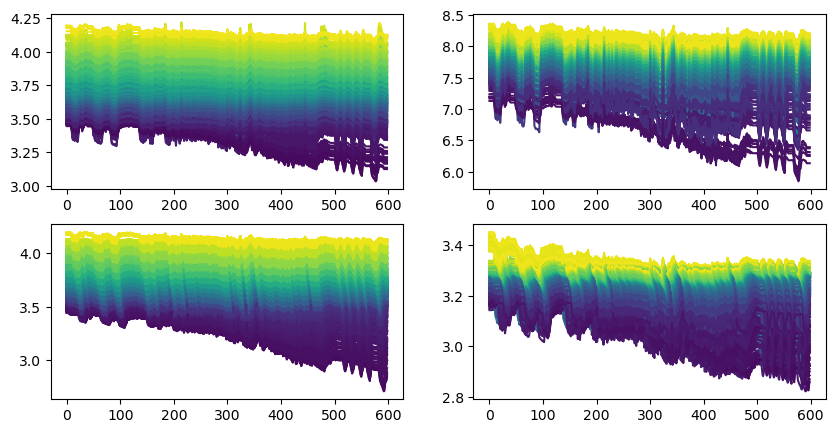

In [ ]:
df = pd.read_csv('../../data/features_charge_depleting_cycles.csv', index_col=0)
df_d = df[df['cell_id'].str.contains('D')]
cmap = cm.get_cmap('viridis', 100)

fig, ax = plt.subplots(2, 2, figsize=(10, 5))
ax = ax.flatten()
for i, row in df[df['cell_id'].str.contains('A')].iterrows():
    ax[0].plot(range(599), row.filter(regex='^voltage').astype(float).to_numpy(), alpha=1, c=cmap(row['soc_mean']))
for i, row in df[df['cell_id'].str.contains('B')].iterrows():
    ax[1].plot(range(599), row.filter(regex='^voltage').astype(float).to_numpy(), alpha=1, c=cmap(row['soc_mean']))
for i, row in df[df['cell_id'].str.contains('C')].iterrows():
    ax[2].plot(range(599), row.filter(regex='^voltage').astype(float).to_numpy(), alpha=1, c=cmap(row['soc_mean']))
for i, row in df[df['cell_id'].str.contains('D')].iterrows():
    ax[3].plot(range(599), row.filter(regex='^voltage').astype(float).to_numpy(), alpha=1, c=cmap(row['soc_mean']))


In [ ]:
def get_charge_cycle(df, cell_id_prefix, cell_id_num, key, segment_length):
    # For a measurement, return collated data from the charge cycle
    if any(["Cell Voltage A1" in col for col in df.columns]):
        col_voltage = "Cell Voltage A1, V"
    else:
        col_voltage = "Voltage, V"

    is_cycle = [
        key in seg_desc for seg_desc in df["Segment Description"]
    ]

    df_seg = retime(df[is_cycle])
    
    # time = df_seg['Segment Time, S']
    time = retime(df_seg)['Segment Time, S']
    soc = df_seg.SOC.to_numpy()
    # temperature = np.mean(df_seg["Temperature A1, °C"].to_numpy())
    voltage = df_seg[col_voltage].to_numpy()
    current = df_seg["Current, A"].to_numpy()
    power = df_seg["Power, W"].to_numpy()

    out = np.vstack((soc, voltage, current, power, time))

    def get_2_closest_cols(df_seg, target_time):
        times = df_seg['Segment Time, S'].to_numpy()
        diffs = np.abs(times - target_time)
        idx_sorted = np.argsort(diffs)
        return (df_seg.iloc[idx_sorted[0]], df_seg.iloc[idx_sorted[1]])

    #interpolate the data at 1 second intervals
    for i in range(time[len(time)-1].round().astype(int)):
        
        if i == 0:
            soc_interp = [soc[0]]
            voltage_interp = [voltage[0]]
            current_interp = [current[0]]
            power_interp = [power[0]]
            time_interp = [i]
            continue

        time_interp += [i]

        # if the two closest points are already at 1 second intervals, just take the closest value
        seg_1, seg_2 = get_2_closest_cols(df_seg, i)
        time_1 = seg_1['Segment Time, S']
        time_2 = seg_2['Segment Time, S']
        if (time_2 - time_1) == 1:
            if time_2 < time_1: #time 2 is the closest point
                soc_interp += [seg_2['SOC']]
                voltage_interp += [seg_2[col_voltage]] 
                current_interp += [seg_2['Current, A']]
                power_interp += [seg_2['Power, W']]
            else:
                soc_interp += [seg_1['SOC']]
                voltage_interp += [seg_1[col_voltage]] 
                current_interp += [seg_1['Current, A']]
                power_interp += [seg_1['Power, W']]
            continue

        #if the two points are within 0.3 seconds of each other, take the average
        if (time_2 - time_1) < 0.3: 
            soc_interp += [(seg_1['SOC'] + seg_2['SOC']) / 2]
            voltage_interp += [(seg_1[col_voltage] + seg_2[col_voltage]) / 2]
            current_interp += [(seg_1['Current, A'] + seg_2['Current, A']) / 2]
            power_interp += [(seg_1['Power, W'] + seg_2['Power, W']) / 2]
            continue
        #finally, if the two closest points are not at 1 second intervals, interpolate
        soc_interp += [np.interp(i, time, soc)]
        voltage_interp += [np.interp(i, time, voltage)]
        current_interp += [np.interp(i, time, current)]
        power_interp += [np.interp(i, time, power)]

    if time_interp[-1] < segment_length:
        print(f"Charge cycle for {cell_id_prefix}_{cell_id_num} is shorter than {segment_length} seconds, skipping")
        return None

    #get 100 random samples of segment_length seconds from the charge cycle
    for i in range(100):
        start_time = np.random.randint(0, len(time_interp) - segment_length)

        voltage_sample = voltage_interp[start_time:start_time + segment_length]
        current_sample = current_interp[start_time:start_time + segment_length]
        power_sample = power_interp[start_time:start_time + segment_length]
        soc_mean = np.mean(soc_interp[start_time:start_time + segment_length])
        soc_initial = soc_interp[start_time]
        soc_final = soc_interp[start_time + segment_length - 1]
        temperature_sample = np.mean(df_seg["Temperature A1, °C"].to_numpy())

        out = np.hstack((temperature_sample, soc_mean, soc_initial, soc_final, voltage_sample, current_sample, power_sample))
        columns = (["temperature", "soc_mean", "soc_initial", "soc_final"] +
                    ["voltage_%3.1fs" % (j) for j in range(segment_length)] +
                    ["current_%3.1fs" % (j) for j in range(segment_length)] +
                    ["power_%3.1fs" % (j) for j in range(segment_length)])

        df_out_sample = pd.Series(out, index=columns)
        if i == 0:
            df_out = pd.DataFrame([df_out_sample])
        elif len(df_out_sample) == segment_length * 3 + 4: # make sure the sample is the correct length
            df_out = pd.concat([df_out, pd.DataFrame([df_out_sample])], ignore_index=True)
        else:
            print(f"sample {i} is the wrong length, skipping")

    return df_out

Charge cycle for D_13 is shorter than 480 seconds, skipping


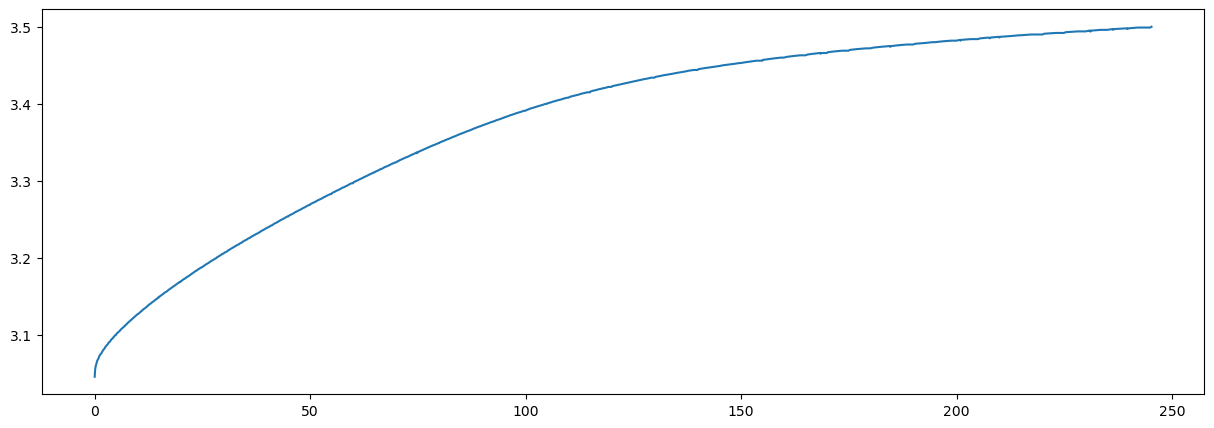

In [ ]:
df = hdf.get('/D/data_240805_ReCellML_A123_cell13_charac_15oC')

df_charge = get_charge_cycle(df, 'D', '13', 'Rate test 1C cycle charge CC', 480)
df_charge = df[df['Segment Description'].str.contains('Rate test 1C cycle charge CC')]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_charge['Segment Time, S'], df_charge['Voltage, V'])
# ax.plot(df['Total Time, S'], df['Voltage, V'])

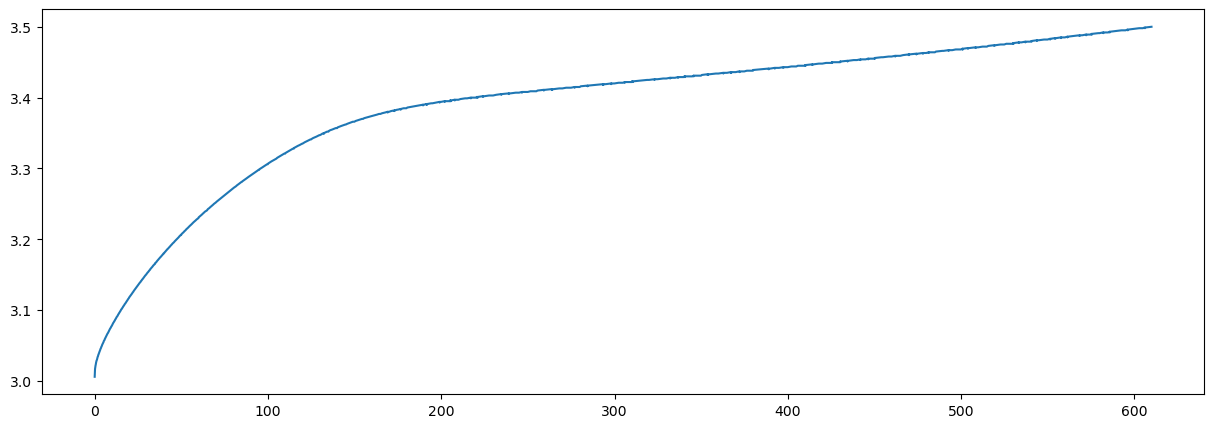

In [ ]:
df = hdf.get('/D/data_240805_ReCellML_A123_cell10_charac_15oC')

df_charge = df[df['Segment Description'].str.contains('Rate test 1C cycle charge CC')]

fig, ax = plt.subplots(figsize=(15, 5))
# ax.plot(df['Total Time, S'], df['Voltage, V'])
ax.plot(df_charge['Segment Time, S'], df_charge['Voltage, V'])

How long are the cycles across battery types? type are are 120 mins for C/2 and 60 mins for 1C, is this consistent?

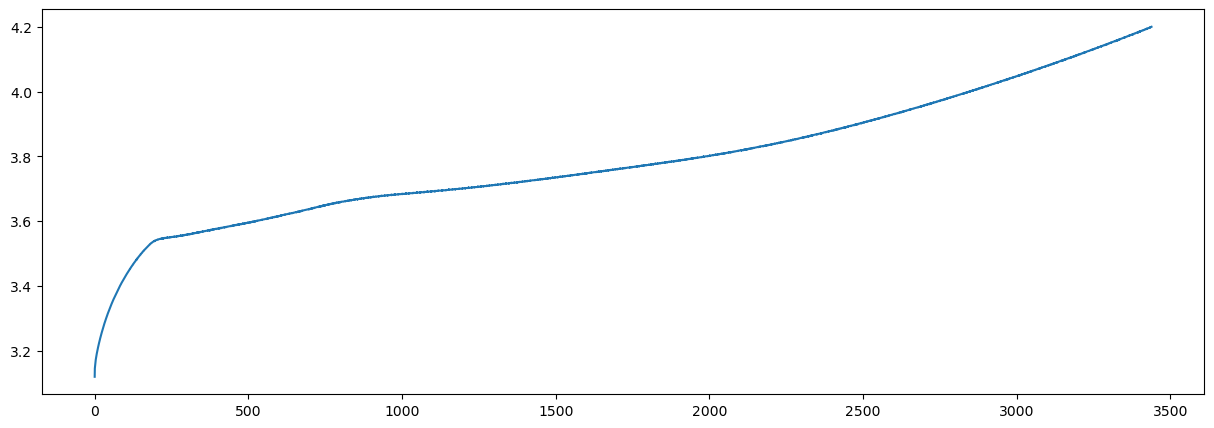

In [ ]:
df = hdf.get('/A/data_230509_ReCellML_A_Cell15_charac_30C')
df = df[df['Segment Description'].str.contains('Rate test 1C cycle charge CC')]
df = retime(df)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df['Segment Time, S'], df['Voltage, V'])

In [1]:
df = pd.HDFStore('../../data/data_raw.h5', mode='r')
keys = [key for key in df.keys() if '/C/' in key]
print(keys)


fig, ax = plt.subplots(2, 4, figsize=(15, 5))
ax = ax.flatten()

segments_of_interest = [
    "Charge depleting cycle",
    "Charge sustaining cycle",
    'Rate test C/2 cycle charge CC',
    'PsRP 1 C/2 diagnostic cycle charge',
    'PsRP 2 C/2 diagnostic cycle charge',
    'Rate test 1C cycle charge CC',
    'PsRP 1 1C diagnostic cycle charge',
    'PsRP 2 1C diagnostic cycle charge',
]

for df in [hdf.get(key) for key in keys]:
    for i, segment in enumerate(segments_of_interest):
        df_segment = df.loc[[segment in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc and 'CV' not in seg_desc for seg_desc in df['Segment Description']]]
        df_segment = retime(df_segment)
        ax[i].plot(df_segment['Segment Time, S'] / 60, df_segment['Voltage, V'], c=cmap(df_segment['Temperature A1, °C'].iloc[0]/45), alpha=0.7)


NameError: name 'pd' is not defined

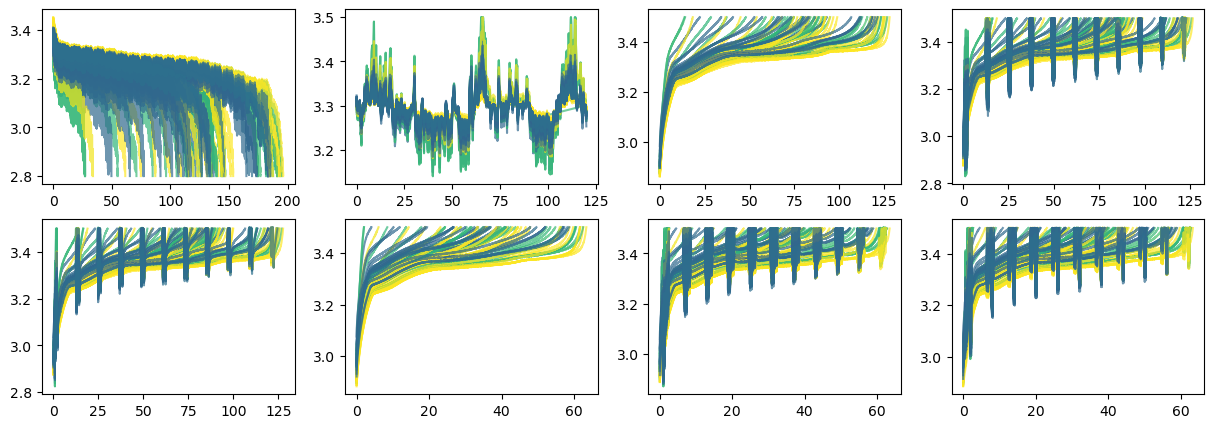

In [ ]:
df = pd.HDFStore('../../data/data_raw.h5', mode='r')
keys = [key for key in df.keys() if '/D/' in key]
fig, ax = plt.subplots(2, 4, figsize=(15, 5))
ax = ax.flatten()
for df in [hdf.get(key) for key in keys]:
    for i, segment in enumerate(segments_of_interest):
        df_segment = df.loc[[segment in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc and 'CV' not in seg_desc for seg_desc in df['Segment Description']]]
        df_segment = retime(df_segment)
        ax[i].plot(df_segment['Segment Time, S'] / 60, df_segment['Voltage, V'], c=cmap(df_segment['Temperature A1, °C'].iloc[0]/45), alpha=0.7)

Fixing the weirdness with the 10 min segments of the charge depleting cycle

In [ ]:
def get_10_min_segments(df, t_length=599):
    # t_length = 599 # for whatever reason, the sequence is 599 seconds long, not 600
    df_segments = []
    _df_ = df.copy().reset_index(drop=True)
    _df_ = retime(_df_)
    _df_['Segment Time, S'] = _df_['Segment Time, S'].to_numpy().round().astype(int)
    t_start = 0
    t_end = t_length
    discontinous = False
    while t_end < _df_['Segment Time, S'].max():
        _df_segment = retime(_df_[(_df_['Segment Time, S'] >= t_start) & (_df_['Segment Time, S'] < t_end)])
        if len(_df_segment) == t_length:
            df_segments.append(_df_segment)
        elif len(_df_segment) > t_length:
            #extra data points, remove everything with a decimal in the segment time
            _df_segment = _df_segment[_df_segment['Segment Time, S'] % 1 == 0]
            if len(_df_segment) == t_length:
                print(f"removed extra data in segment starting at {t_start} seconds")
                df_segments.append(_df_segment)
            else:
                print(f"found extra data in 10 min segment starting at {t_start} seconds, unable to remove")
        else:
            print(f"found short segment starting at {t_start} seconds, only {len(_df_segment)} data points")
        t_start += t_length
        t_end += t_length
    return df_segments

def get_charge_depleting_cycle(df, pattern_length):
    # For a measurement, return collated data from the charge-depleting cycle
    if any(["Cell Voltage A1" in col for col in df.columns]):
        col_voltage = "Cell Voltage A1, V"
    else:
        col_voltage = "Voltage, V"

    is_cycle = [
        "Charge depleting cycle" in seg_desc for seg_desc in df["Segment Description"]
    ]

    #split the repeating charge depleting cycles into individual 10 min cycles
    dfs = get_10_min_segments(df[is_cycle], pattern_length)
    time = dfs[0]['Segment Time, S']

    # mask_priorvoltage = [False] * len(is_cycle) # not sure this is needed
    # len(is_cycle) - len(mask_priorvoltage)

    df_testing = []
    df_training = []

    for df in dfs:
        # save last 120 seconds of data separately
        df_last_120s = df[-120:]
        df.drop(df.index[-120:], inplace=True)
        df.reset_index(drop=True, inplace=True)

        df_last_120s.reset_index(drop=True, inplace=True)
        df_testing += [df_last_120s]

        for i in range(5):
            start_time = np.random.randint(0, len(df) - 120) # random start time for 8 min segment
            df_segment = df[start_time:start_time + 120]
            df_segment.reset_index(drop=True, inplace=True)
            df_training += [df_segment]

    time = df_testing[0]['Segment Time, S'] - 479 # reset time to start from 0  

    for i, t in enumerate(time):
        if i == 0:
            columns_soc = ["soc_%3.1fs" % (t)]
            columns_voltage = ["voltage_%3.1fs" % (t)]
            columns_current = ["current_%3.1fs" % (t)]
            columns_power = ["power_%3.1fs" % (t)]
        else:
            columns_soc += ["soc_%3.1fs" % (t)]
            columns_voltage += ["voltage_%3.1fs" % (t)]
            columns_current += ["current_%3.1fs" % (t)]
            columns_power += ["power_%3.1fs" % (t)]

    for i, df_seg in enumerate(df_testing):
        if i == 0:
            soc_mean = df_seg.SOC.to_numpy().mean()
            soc_initial = df_seg.SOC.to_numpy()[0]
            soc_final = df_seg.SOC.to_numpy()[-1]
            temperature = np.mean(df_seg["Temperature A1, °C"].to_numpy())
            voltage = df_seg[col_voltage].to_numpy()
            current = df_seg["Current, A"].to_numpy()
            power = df_seg["Power, W"].to_numpy()
            type = [['testing']]
        else:
            soc_mean = np.vstack((soc_mean, df_seg.SOC.to_numpy().mean()))
            soc_initial = np.vstack((soc_initial, df_seg.SOC.to_numpy()[0]))
            soc_final = np.vstack((soc_final, df_seg.SOC.to_numpy()[-1]))
            temperature = np.vstack((temperature, np.mean(df_seg["Temperature A1, °C"].to_numpy())))
            voltage = np.vstack((voltage, df_seg[col_voltage].to_numpy()))
            current = np.vstack((current, df_seg["Current, A"].to_numpy()))
            power = np.vstack((power, df_seg["Power, W"].to_numpy()))
            type += [['testing']]

    for i, df_seg in enumerate(df_training):
        soc_mean = np.vstack((soc_mean, df_seg.SOC.to_numpy().mean()))
        soc_initial = np.vstack((soc_initial, df_seg.SOC.to_numpy()[0]))
        soc_final = np.vstack((soc_final, df_seg.SOC.to_numpy()[-1]))
        temperature = np.vstack((temperature, np.mean(df_seg["Temperature A1, °C"].to_numpy())))
        voltage = np.vstack((voltage, df_seg[col_voltage].to_numpy()))
        current = np.vstack((current, df_seg["Current, A"].to_numpy()))
        power = np.vstack((power, df_seg["Power, W"].to_numpy()))
        type += [['training']]

    out = np.hstack((temperature, soc_mean, soc_initial, soc_final, type, voltage, current, power))
    columns = (["temperature", "soc_mean", "soc_initial", "soc_final", "split_type"] + columns_voltage + columns_current + columns_power)

    df_out = pd.DataFrame(out, columns=columns)

    return df_out

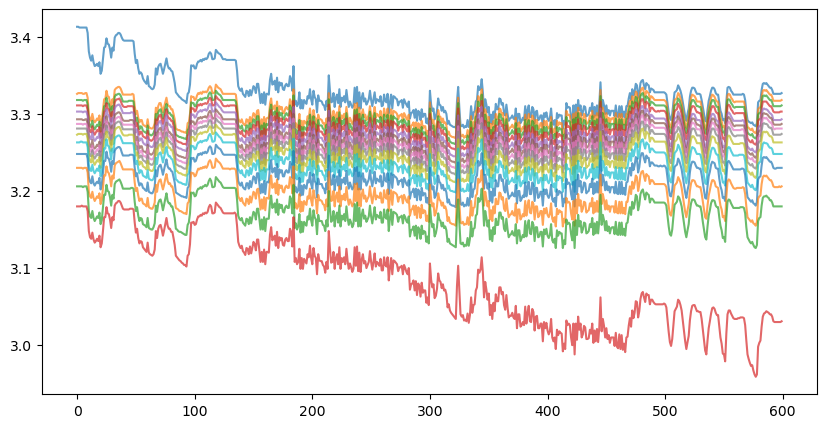

In [ ]:
# df = hdf.get('/D/data_240805_ReCellML_A123_cell13_charac_15oC')
df = hdf.get('/D/data_240624_ReCellML_A123_Cell06_charac_30C')
# df = hdf.get('/C/data_231115_ReCellML_C_Cell01_charac_45oC')
df = df[df['Segment Description'].str.contains('Charge depleting cycle')]

ten_min_cycles = get_10_min_segments(df, t_length=600)
fig, ax = plt.subplots(figsize=(10, 5))

for cycle in ten_min_cycles:
    ax.plot(cycle['Segment Time, S'], cycle['Voltage, V'], alpha=0.7)


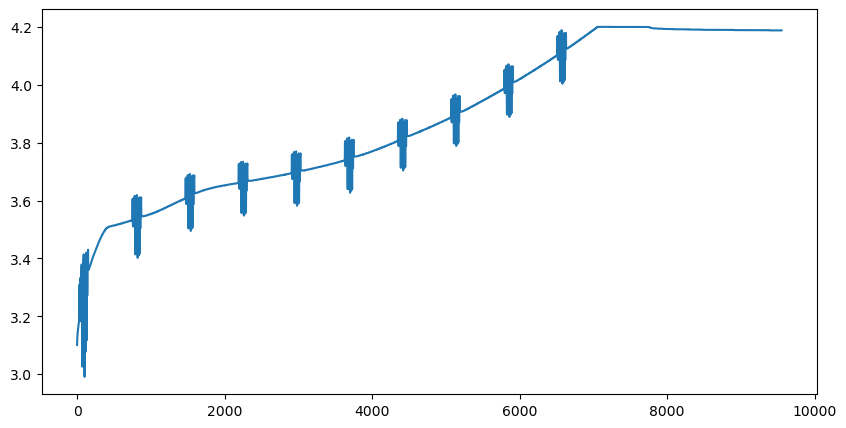

In [ ]:
df = hdf.get('/A/data_230509_ReCellML_A_Cell15_charac_30C')

key = "PsRP 1 C/2 diagnostic cycle charge"

# For a measurement, return collated data from the charge cycle
if any(["Cell Voltage A1" in col for col in df.columns]):
    col_voltage = "Cell Voltage A1, V"
else:
    col_voltage = "Voltage, V"

is_cycle = [
    key in seg_desc for seg_desc in df["Segment Description"]
]

df_seg = retime(df[is_cycle])

# time = df_seg['Segment Time, S']
time = retime(df_seg)['Segment Time, S']
soc = df_seg.SOC.to_numpy()
# temperature = np.mean(df_seg["Temperature A1, °C"].to_numpy())
voltage = df_seg[col_voltage].to_numpy()
current = df_seg["Current, A"].to_numpy()
power = df_seg["Power, W"].to_numpy()

out = np.vstack((soc, voltage, current, power, time))

def get_2_closest_cols(df_seg, target_time):
    times = df_seg['Segment Time, S'].to_numpy()
    diffs = np.abs(times - target_time)
    idx_sorted = np.argsort(diffs)
    return (df_seg.iloc[idx_sorted[0]], df_seg.iloc[idx_sorted[1]])

#interpolate the data at 1 second intervals
for i in range(time[len(time)-1].round().astype(int)):
    
    if i == 0:
        soc_interp = [soc[0]]
        voltage_interp = [voltage[0]]
        current_interp = [current[0]]
        power_interp = [power[0]]
        time_interp = [i]
        continue

    time_interp += [i]

    # if the two closest points are already at 1 second intervals, just take the closest value
    seg_1, seg_2 = get_2_closest_cols(df_seg, i)
    time_1 = seg_1['Segment Time, S']
    time_2 = seg_2['Segment Time, S']
    if (time_2 - time_1) == 1:
        if time_2 < time_1: #time 2 is the closest point
            soc_interp += [seg_2['SOC']]
            voltage_interp += [seg_2[col_voltage]] 
            current_interp += [seg_2['Current, A']]
            power_interp += [seg_2['Power, W']]
        else:
            soc_interp += [seg_1['SOC']]
            voltage_interp += [seg_1[col_voltage]] 
            current_interp += [seg_1['Current, A']]
            power_interp += [seg_1['Power, W']]
        continue

    #if the two points are within 0.3 seconds of each other, take the average
    if (time_2 - time_1) < 0.3: 
        soc_interp += [(seg_1['SOC'] + seg_2['SOC']) / 2]
        voltage_interp += [(seg_1[col_voltage] + seg_2[col_voltage]) / 2]
        current_interp += [(seg_1['Current, A'] + seg_2['Current, A']) / 2]
        power_interp += [(seg_1['Power, W'] + seg_2['Power, W']) / 2]
        continue
    #finally, if the two closest points are not at 1 second intervals, interpolate
    soc_interp += [np.interp(i, time, soc)]
    voltage_interp += [np.interp(i, time, voltage)]
    current_interp += [np.interp(i, time, current)]
    power_interp += [np.interp(i, time, power)]

if time_interp[-1] < 600:
    print(f"Charge cycle for {cell_id_prefix}_{cell_id_num} is shorter than {600} seconds, skipping")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time_interp, voltage_interp)

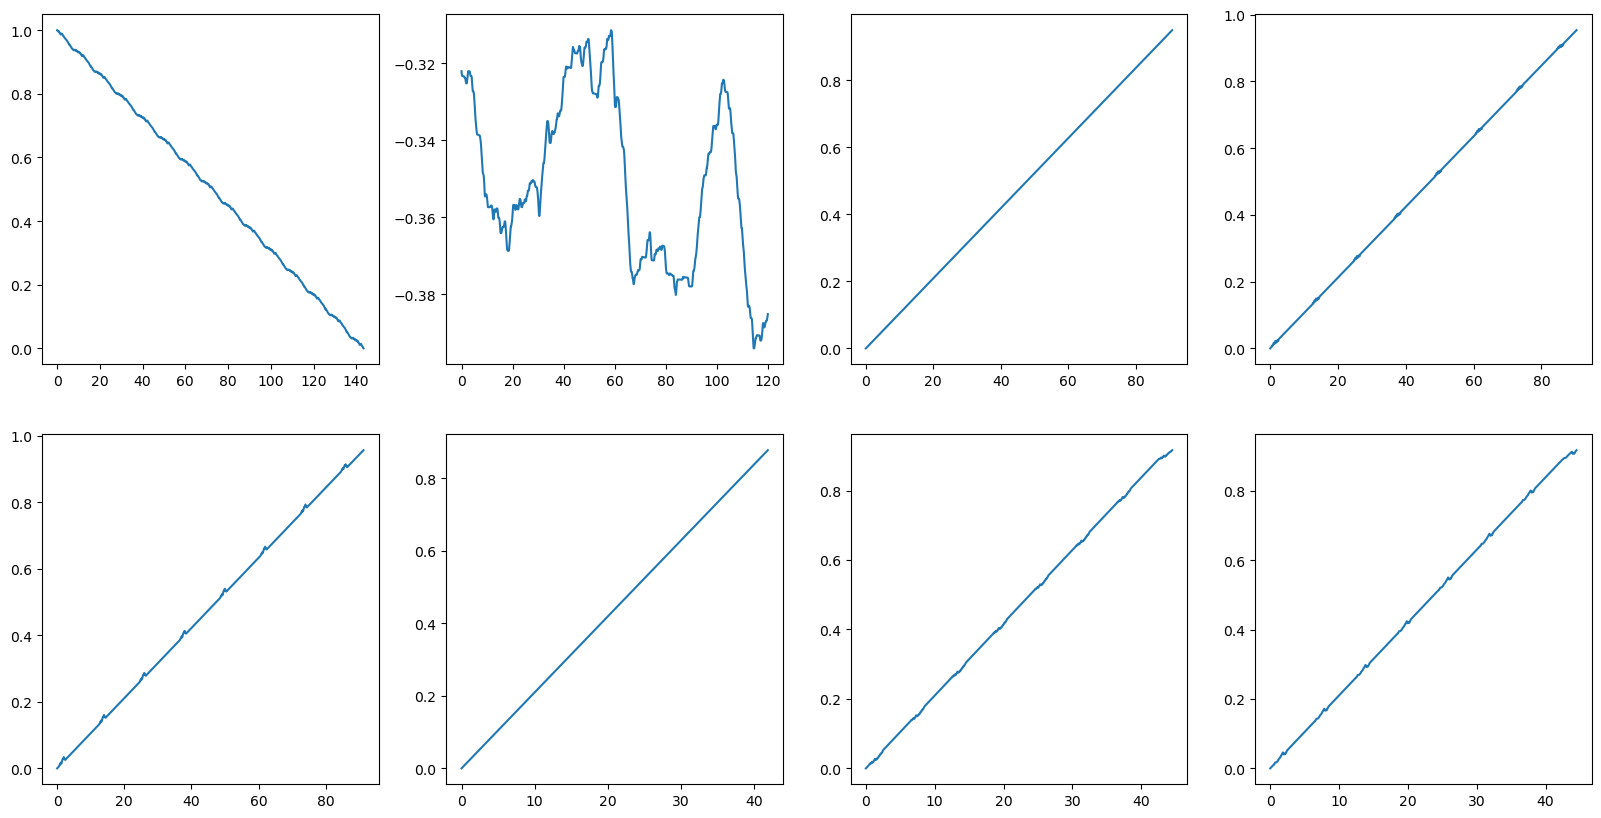

In [19]:
df = hdf2.get('/D/data_240624_ReCellML_A123_Cell06_charac_30C')

fig, ax = plt.subplots(2, 4, figsize=(20, 10))
ax = ax.flatten()
for i, segment in enumerate(segments_of_interest):
    # filter df for any rows where the col 'Segment Description' contains segment
    df_segment = df.loc[[segment in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc for seg_desc in df['Segment Description']]]
    df_segment = retime(df_segment)
    ax[i].plot(df_segment['Segment Time, S'] / 60, df_segment['SOC'])

In [9]:
hdf = pd.HDFStore('../../data/data_partial_charge_for_ml.h5', mode='r')

df = hdf.get('/Charge_Sustaining')

sample = df[df['split_type'] == 'training'].groupby(by='measurement_id').sample(frac=0.1, random_state=42)
testing = df[df['split_type'] == 'testing']

# sample.groupby(by='measurement_id').count()
pd.concat([testing, sample], ignore_index=True).groupby(by='measurement_id').count()


,soc_mean,soc_initial,soc_final,split_type,voltage_ 0.0s,voltage_ 4.0s,voltage_ 8.0s,voltage_ 12.0s,voltage_ 16.0s,voltage_ 20.0s,...,Charge depleting cycle charge throughput,Charge sustaining cycle charge efficiency,Post C/10 charge relaxation fit MSE,Post C/5 charge relaxation fit MSE,Post C/3 charge relaxation fit MSE,Post P/3 charge relaxation fit MSE,Post C/2 charge relaxation fit MSE,Post 1C charge relaxation fit MSE,Thickness growth,Volume growth
measurement_id,,,,,,,,,,,,,,,,,,,,,
0,6,6,6,6,6,6,6,6,6,6,...,6,6,6,6,6,6,6,6,0,0
1,6,6,6,6,6,6,6,6,6,6,...,6,6,6,6,6,6,6,6,0,0
2,6,6,6,6,6,6,6,6,6,6,...,6,6,6,6,6,6,6,6,0,0
3,6,6,6,6,6,6,6,6,6,6,...,6,6,6,6,6,6,6,6,0,0
4,6,6,6,6,6,6,6,6,6,6,...,6,6,6,6,6,6,6,6,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,6,6,6,6,6,6,6,6,6,6,...,6,6,6,6,6,6,6,6,0,0
251,6,6,6,6,6,6,6,6,6,6,...,6,6,6,6,6,6,6,6,0,0
252,6,6,6,6,6,6,6,6,6,6,...,6,6,6,6,6,6,6,6,0,0


In [4]:
hdf2 = pd.HDFStore('../../data/data_raw.h5', mode='r')
df2 = hdf2.get('/C/data_240109_ReCellML_C_TX_Cell74_charac_chain_15oC')
df2 = df2[df2['Segment Description'].str.contains('Charge sustaining cycle')]

df3 = hdf2.get('/D/data_240624_ReCellML_A123_Cell06_charac_30C')
df3 = df3[df3['Segment Description'].str.contains('Charge sustaining cycle')]

fig, ax = plt.subplots(1,2,figsize=(10, 5))

ax[0].plot(df2['Segment Time, S'], df2['SOC'])
ax[1].plot(df3['Segment Time, S'], df3['SOC'])

: 

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_44328\2083365675.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 100)


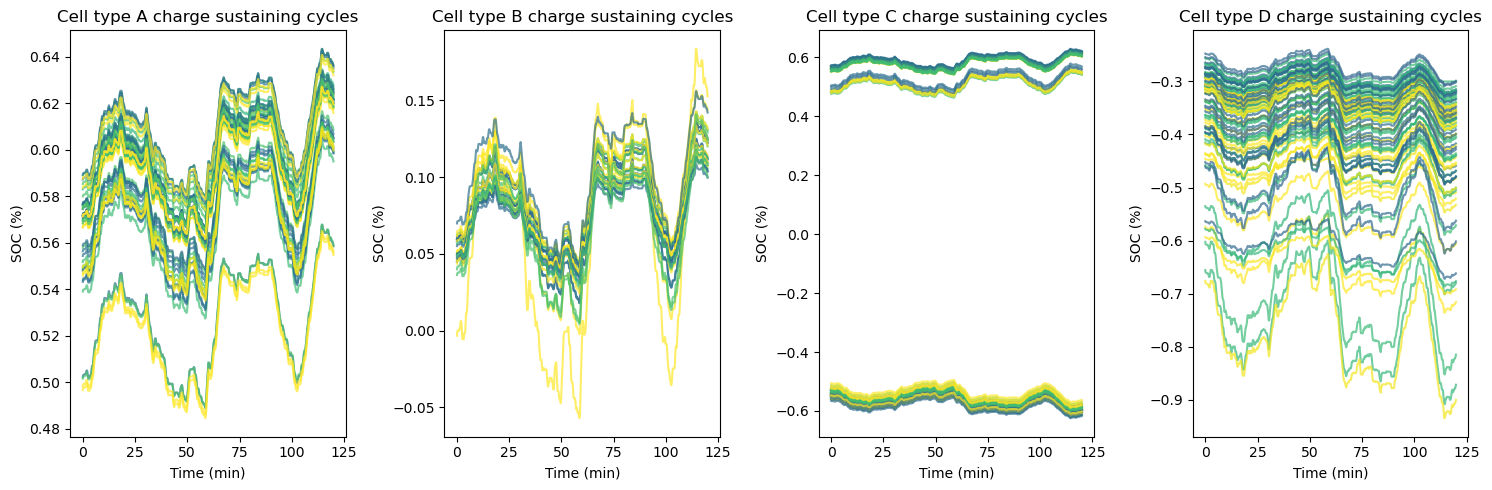

In [11]:
cmap = cm.get_cmap('viridis', 100)
cell_types = {
    'A':0, 
    'B':1, 
    'C':2,
    'D':3
}

keys = hdf2.keys()

fig, ax = plt.subplots(1,4,figsize=(15,5))

for key in keys:
    df = hdf2.get(key)
    df = df[df['Segment Description'].str.contains('Charge sustaining cycle')]
    ax[cell_types[key[1]]].plot(df['Segment Time, S']/60, df['SOC'], c=cmap(df['Temperature A1, °C'].iloc[0]/45), alpha=0.7)
for cell in cell_types:
    ax[cell_types[cell]].set_title(f'Cell type {cell} charge sustaining cycles')
    ax[cell_types[cell]].set_xlabel('Time (min)')
    ax[cell_types[cell]].set_ylabel('SOC (%)')

fig.tight_layout()

<Axes: xlabel='cell_id', ylabel='soc_mean'>

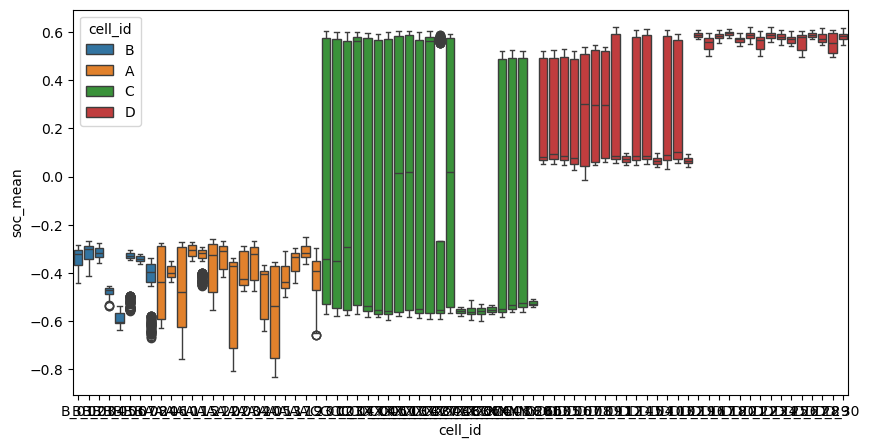

In [10]:
fig, ax = plt.subplots(figsize=(10,5))

sns.boxplot(data=df, x='cell_id', y='soc_mean', ax=ax, hue=df['cell_id'].str[0])

In [8]:
df[df['cell_id'].str.contains('C')]

,soc_mean,soc_initial,soc_final,split_type,voltage_ 0.0s,voltage_ 4.0s,voltage_ 8.0s,voltage_ 12.0s,voltage_ 16.0s,voltage_ 20.0s,...,Charge depleting cycle charge throughput,Charge sustaining cycle charge efficiency,Post C/10 charge relaxation fit MSE,Post C/5 charge relaxation fit MSE,Post C/3 charge relaxation fit MSE,Post P/3 charge relaxation fit MSE,Post C/2 charge relaxation fit MSE,Post 1C charge relaxation fit MSE,Thickness growth,Volume growth
3876,-0.360471,-0.383437,-0.390551,testing,3.306,3.306,3.306,3.306,3.300,3.288,...,34.201981,1.293836,1.480000e-07,1.560000e-07,1.530000e-07,1.560000e-07,0.000002,0.000003,NaN,NaN
3877,-0.328811,-0.332772,-0.381048,training,3.268,3.269,3.269,3.269,3.258,3.255,...,34.201981,1.293836,1.480000e-07,1.560000e-07,1.530000e-07,1.560000e-07,0.000002,0.000003,NaN,NaN
3878,-0.334778,-0.319214,-0.375710,training,3.264,3.264,3.264,3.264,3.265,3.265,...,34.201981,1.293836,1.480000e-07,1.560000e-07,1.530000e-07,1.560000e-07,0.000002,0.000003,NaN,NaN
3879,-0.344446,-0.371194,-0.318529,training,3.348,3.351,3.346,3.347,3.349,3.347,...,34.201981,1.293836,1.480000e-07,1.560000e-07,1.530000e-07,1.560000e-07,0.000002,0.000003,NaN,NaN
3880,-0.339602,-0.314767,-0.376481,training,3.265,3.265,3.265,3.265,3.266,3.266,...,34.201981,1.293836,1.480000e-07,1.560000e-07,1.530000e-07,1.560000e-07,0.000002,0.000003,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8665,0.508337,0.474248,0.529006,training,3.711,3.708,3.705,3.717,3.718,3.725,...,25.198747,1.282383,4.250000e-07,5.880000e-07,5.600000e-07,5.500000e-07,0.000007,0.000009,0.101542,0.080544
8666,0.494756,0.519446,0.486067,training,3.743,3.740,3.754,3.754,3.754,3.754,...,25.198747,1.282383,4.250000e-07,5.880000e-07,5.600000e-07,5.500000e-07,0.000007,0.000009,0.101542,0.080544
8667,0.515445,0.511652,0.493845,training,3.773,3.777,3.784,3.796,3.804,3.807,...,25.198747,1.282383,4.250000e-07,5.880000e-07,5.600000e-07,5.500000e-07,0.000007,0.000009,0.101542,0.080544
8668,0.515222,0.483699,0.499508,training,3.739,3.750,3.751,3.751,3.738,3.738,...,25.198747,1.282383,4.250000e-07,5.880000e-07,5.600000e-07,5.500000e-07,0.000007,0.000009,0.101542,0.080544


In [16]:
def get_charge_cycle_time_variable(df, cell_id_prefix, cell_id_num, key):

    # For a measurement, return collated data from the charge cycle
    if any(["Cell Voltage A1" in col for col in df.columns]):
        col_voltage = "Cell Voltage A1, V"
    else:
        col_voltage = "Voltage, V"

    is_cycle = [
        key in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc for seg_desc in df["Segment Description"]
    ]

    df_seg = retime(df[is_cycle])
    
    # time = df_seg['Segment Time, S']
    time = retime(df_seg)['Segment Time, S']
    soc = df_seg.SOC.to_numpy()
    # temperature = np.mean(df_seg["Temperature A1, °C"].to_numpy())
    voltage = df_seg[col_voltage].to_numpy()
    current = df_seg["Current, A"].to_numpy()
    power = df_seg["Power, W"].to_numpy()

    out = np.vstack((soc, voltage, current, power, time))

    def get_2_closest_cols(df_seg, target_time):
        times = df_seg['Segment Time, S'].to_numpy()
        diffs = np.abs(times - target_time)
        idx_sorted = np.argsort(diffs)
        return (df_seg.iloc[idx_sorted[0]], df_seg.iloc[idx_sorted[1]])

    #interpolate the data at 1 second intervals
    for i in range(time[len(time)-1].round().astype(int)):
        
        if i == 0:
            soc_interp = [soc[0]]
            voltage_interp = [voltage[0]]
            current_interp = [current[0]]
            power_interp = [power[0]]
            time_interp = [i]
            continue

        time_interp += [i]

        
        seg_1, seg_2 = get_2_closest_cols(df_seg, i)
        time_1 = seg_1['Segment Time, S']
        time_2 = seg_2['Segment Time, S']

        # save the closer of the two points
        if time_2 < time_1:
            soc_interp += [seg_2['SOC']]
            voltage_interp += [seg_2[col_voltage]]
            current_interp += [seg_2['Current, A']]
            power_interp += [seg_2['Power, W']]
        else:
            soc_interp += [seg_1['SOC']]
            voltage_interp += [seg_1[col_voltage]]
            current_interp += [seg_1['Current, A']]
            power_interp += [seg_1['Power, W']]

        # if the segments are more than 10 seconds apart, panic, there is data missing
        if (time_2 - time_1 > 10) or (time_1 - time_2 > 10): 
            print(f"PANIC PANIC {key} PANIC PANIC ")

        # if the two closest points are already at 1 second intervals, just take the closest value
        # if (time_2 - time_1) == 1:
        #     if time_2 < time_1: #time 2 is the closest point
        #         soc_interp += [seg_2['SOC']]
        #         voltage_interp += [seg_2[col_voltage]] 
        #         current_interp += [seg_2['Current, A']]
        #         power_interp += [seg_2['Power, W']]
        #     else:
        #         soc_interp += [seg_1['SOC']]
        #         voltage_interp += [seg_1[col_voltage]] 
        #         current_interp += [seg_1['Current, A']]
        #         power_interp += [seg_1['Power, W']]
        #     continue

        # #if the two points are within 0.3 seconds of each other, take the average
        # if (time_2 - time_1) < 0.3: 
        #     soc_interp += [(seg_1['SOC'] + seg_2['SOC']) / 2]
        #     voltage_interp += [(seg_1[col_voltage] + seg_2[col_voltage]) / 2]
        #     current_interp += [(seg_1['Current, A'] + seg_2['Current, A']) / 2]
        #     power_interp += [(seg_1['Power, W'] + seg_2['Power, W']) / 2]
        #     continue
        # #finally, if the two closest points are not at 1 second intervals, interpolate
        # soc_interp += [np.interp(i, time, soc)]
        # voltage_interp += [np.interp(i, time, voltage)]
        # current_interp += [np.interp(i, time, current)]
        # power_interp += [np.interp(i, time, power)]

    segment_lengths = {
        "fifteen_mins": 900,
        "thirty_mins": 1800,
        "fortyfive_mins": 2700,
        "sixty_mins": 3600
    }

    segs_15 = []
    segs_30 = []
    segs_45 = []
    segs_60 = []

    df_segments = [
        segs_15,
        segs_30,
        segs_45,
        segs_60
    ]

    df_results = []

    

    for (j, df_time_samples), (key, segment_length) in zip(enumerate(df_segments), segment_lengths.items()):
        print(j)
        if time_interp[-1] < segment_length:
            print(f"Charge cycle for {cell_id_prefix}_{cell_id_num} is shorter than {segment_length} seconds, skipping")
            continue

        #decide how many random samples to take from the charge cycle
        # sample_size = 10 * -(time_interp[-1] // -segment_length) #ceiling division
        sample_size = 100

        #get sample_size random samples of segment_length seconds from the charge cycle
        for i in range(sample_size):
            start_time = np.random.randint(0, len(time_interp) - segment_length)

            voltage_sample = voltage_interp[start_time:start_time + segment_length]
            current_sample = current_interp[start_time:start_time + segment_length]
            power_sample = power_interp[start_time:start_time + segment_length]
            soc_mean = np.mean(soc_interp[start_time:start_time + segment_length])
            soc_initial = soc_interp[start_time]
            soc_final = soc_interp[start_time + segment_length - 1]
            temperature_sample = np.mean(df_seg["Temperature A1, °C"].to_numpy())
            segment_length_array = [key]

            out = np.hstack((temperature_sample, soc_mean, soc_initial, soc_final, segment_length_array, voltage_sample, current_sample, power_sample))

            # df_out_sample = pd.Series(out, index=columns)
            if len(out) == segment_length * 3 + 5: # make sure the sample is the correct length
                df_time_samples += [out]
            else:
                print(f"sample {i} is the wrong length, skipping")

            # if i == 0:
            #     df_out = pd.DataFrame([df_out_sample])
            # elif len(df_out_sample) == segment_length * 3 + 5: # make sure the sample is the correct length
            #     df_out = pd.concat([df_out, pd.DataFrame([df_out_sample])], ignore_index=True)
            # else:
            #     print(f"sample {i} is the wrong length, skipping")

        columns = (["temperature", "soc_mean", "soc_initial", "soc_final", "segment_length"] +
            ["voltage_%3.1fs" % (j) for j in range(segment_length)] +
            ["current_%3.1fs" % (j) for j in range(segment_length)] +
            ["power_%3.1fs" % (j) for j in range(segment_length)])

        # if j == 0:
        #     df_out = pd.DataFrame(df_time_samples, columns=columns)
        # else:
        #     df_out = pd.concat([df_out, pd.DataFrame(df_time_samples, columns=columns)], ignore_index=True)
    
        df_results.append(pd.DataFrame(df_time_samples, columns=columns))
    # out = np.vstack(df_time_samples)

    for i, df in enumerate(df_results):
        if i == 0:
            df_out = df
        else:
            df_out = pd.concat([df_out, df], ignore_index=True)
        
    return df_out

def get_charge_sustaining_cycle_time_variable(df, cell_id_prefix):
    if any(["Cell Voltage A1" in col for col in df.columns]):
        col_voltage = "Cell Voltage A1, V"
    else:
        col_voltage = "Voltage, V"

    is_cycle = [
        "Charge sustaining cycle" in seg_desc for seg_desc in df["Segment Description"]
    ]

    df_seg = df[is_cycle]
    # time = df_seg['Segment Time, S']
    time = retime(df_seg)['Segment Time, S']

    # mask_priorvoltage = [False] * len(is_cycle) # not sure this is needed
    # len(is_cycle) - len(mask_priorvoltage)

    

    if cell_id_prefix.startswith('A') or cell_id_prefix.startswith('B'):
        # voltage resolution is every 1 sec
        resolution = 1
    else: 
        # voltage resolution is every 4 secs
        resolution = 4

    # check for large gaps in time data, or extra data points
    for i in range(len(time)-1):
        if time[i+1] - time[i] > resolution + 0.1:
            print(f"Large time gap found in charge sustaining cycle, check data quality")
            return None
        elif time[i+1] - time[i] < resolution - 0.1:
            print(f"Extra time data found in charge sustaining cycle, removing data")
            mask_keep = df_seg['Segment Time, S'] % resolution == 0
            df_seg = df_seg[mask_keep]
            df_seg = retime(df_seg)

    segment_lengths = {
        "fifteen_mins": int(900 / resolution),
        "thirty_mins": int(1800 / resolution),
        "fortyfive_mins": int(2700 / resolution),
        "sixty_mins": int(3600 / resolution)
    }

    segs_15 = []
    segs_30 = []
    segs_45 = []
    segs_60 = []

    df_segments = [
        segs_15,
        segs_30,
        segs_45,
        segs_60
    ]


    # # save last 30 mins (1800s) of data separately
    # thirty_mins = int(1800 / resolution)
    # df_testing = retime(df_seg[-thirty_mins:])

    # df_seg.drop(df_seg.index[-thirty_mins:], inplace=True)
    # df_seg.reset_index(drop=True, inplace=True)
    # df_seg = retime(df_seg)
    for (j, df_time_samples), (key, length) in zip(enumerate(df_segments), segment_lengths.items()):
        for i in range(50):
            start_time = np.random.randint(0, len(df_seg) - length) # random start time for segment
            df_segment = df_seg[start_time:start_time + length]
            df_segment.reset_index(drop=True, inplace=True)
            df_segment["segment_length"] = key
            df_time_samples += [df_segment]

        # time = df_testing['Segment Time, S'] - (df_testing['Segment Time, S'].iloc[0]) # reset time to start from 0
        time = df_time_samples[-1]['Segment Time, S'] - (df_time_samples[-1]['Segment Time, S'].iloc[0]) # reset time to start from 0

        for i, t in enumerate(time):
            if i == 0:
                # columns_soc = ["soc_%5.1fs" % (t)]
                columns_voltage = ["voltage_%5.1fs" % (t)]
                columns_current = ["current_%5.1fs" % (t)]
                columns_power = ["power_%5.1fs" % (t)]
            else:
                # columns_soc += ["soc_%5.1fs" % (t)]
                columns_voltage += ["voltage_%5.1fs" % (t)]
                columns_current += ["current_%5.1fs" % (t)]
                columns_power += ["power_%5.1fs" % (t)]

        # soc = df_seg.SOC.to_numpy()
        

        for i, row in enumerate(df_time_samples):
            if i == 0:
                soc_mean = row.SOC.to_numpy().mean()
                soc_initial = row.SOC.to_numpy()[0]
                soc_final = row.SOC.to_numpy()[-1]
                temperature = np.mean(row["Temperature A1, °C"].to_numpy())
                voltage = row[col_voltage].to_numpy()
                current = row["Current, A"].to_numpy()
                power = row["Power, W"].to_numpy()
                segment_length = [row["segment_length"].iloc[0]]
            else:
                soc_mean = np.vstack((soc_mean, row.SOC.to_numpy().mean()))
                soc_initial = np.vstack((soc_initial, row.SOC.to_numpy()[0]))
                soc_final = np.vstack((soc_final, row.SOC.to_numpy()[-1]))
                temperature = np.vstack((temperature, np.mean(row["Temperature A1, °C"].to_numpy())))
                voltage = np.vstack((voltage, row[col_voltage].to_numpy()))
                current = np.vstack((current, row["Current, A"].to_numpy()))
                power = np.vstack((power, row["Power, W"].to_numpy()))
                segment_length = np.vstack((segment_length, [row["segment_length"].iloc[0]]))


        out = np.hstack((temperature, soc_mean, soc_initial, soc_final, segment_length, voltage, current, power))
        columns = (["temperature", "soc_mean", "soc_initial", "soc_final", "segment_length"] + columns_voltage + columns_current + columns_power)
        if j == 0:
            df_out = pd.DataFrame(out, columns=columns)
        else:
            df_out = pd.concat([df_out, pd.DataFrame(out, columns=columns)], ignore_index=True)

    return df_out

# hdf = pd.HDFStore('../../data/data_raw.h5', mode='r')
# df = hdf.get('/A/data_230509_ReCellML_A_Cell15_charac_30C')

# df3 = df[df['Segment Description'].str.contains('Rate test 1C cycle charge CC')]

# df2 = get_charge_cycle_time_variable(df, 'A', '15', 'Rate test 1C cycle charge CC')

# df2

In [36]:
# get first 5 keys
keys = hdf.keys()[:3]
import re
collated_data = []


for i, key in enumerate(keys):
    print(key)
    df = hdf.get(key)
    # cell id
    cell_id_num = re.search(r"[Cc]ell\d\d", key).group()[-2:]
    # modifiers by cell type
    if "_A_" in key:
        cell_id_prefix = "A_"
        nominal_capacity = 64
        charge_depleting_pattern_length = 599 # seconds
    elif "Leaf" in key:
        cell_id_prefix = "B_"
        nominal_capacity = 66
        charge_depleting_pattern_length = 599 # seconds
    elif "_C_" in key:
        nominal_capacity = 26
        charge_depleting_pattern_length = 600 # seconds
        if "_TX" in key:
            cell_id_prefix = "C_TX_"
        else:
            cell_id_prefix = "C_"
    elif "A123" in key:
        nominal_capacity = 2.3
        cell_id_prefix = "D_"
        charge_depleting_pattern_length = 600 # seconds

    _df_charge_sustaining_time_variable = get_charge_sustaining_cycle_time_variable(df, cell_id_prefix) #, nominal_capacity)
    _df_psrp_2_C2_time_variable = get_charge_cycle_time_variable(df, cell_id_prefix, cell_id_num, "PsRP 2 C/2 diagnostic cycle charge") #, nominal_capacity)  


    data = [_df_psrp_2_C2_time_variable, _df_charge_sustaining_time_variable]
    cell_id = cell_id_prefix + cell_id_num
    measurement_id = i
    for i, _df in enumerate(data):
        if _df is None:
            continue
        new_df = _df.copy()
        new_df["measurement_id"] = measurement_id
        new_df["cell_id"] = cell_id
        if key == keys[0]:
            collated_data.append(new_df)
        else:
            collated_data[i] = pd.concat([collated_data[i], new_df])

    del df


/D/data_240624_ReCellML_A123_Cell01_charac_30C


C:\Users\etenney\AppData\Local\Temp\1\ipykernel_19356\307204581.py:243: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment["segment_length"] = key
C:\Users\etenney\AppData\Local\Temp\1\ipykernel_19356\307204581.py:243: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment["segment_length"] = key
C:\Users\etenney\AppData\Local\Temp\1\ipykernel_19356\307204581.py:243: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

0
1
2
3
/D/data_240624_ReCellML_A123_Cell03_charac_30C


C:\Users\etenney\AppData\Local\Temp\1\ipykernel_19356\307204581.py:243: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment["segment_length"] = key
C:\Users\etenney\AppData\Local\Temp\1\ipykernel_19356\307204581.py:243: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment["segment_length"] = key
C:\Users\etenney\AppData\Local\Temp\1\ipykernel_19356\307204581.py:243: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

0
1
2
3
/D/data_240624_ReCellML_A123_Cell05_charac_30C


C:\Users\etenney\AppData\Local\Temp\1\ipykernel_19356\307204581.py:243: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment["segment_length"] = key
C:\Users\etenney\AppData\Local\Temp\1\ipykernel_19356\307204581.py:243: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_segment["segment_length"] = key
C:\Users\etenney\AppData\Local\Temp\1\ipykernel_19356\307204581.py:243: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

0
1
2
3


In [31]:
collated_data[0]

,temperature,soc_mean,soc_initial,soc_final,segment_length,voltage_0.0s,voltage_1.0s,voltage_2.0s,voltage_3.0s,voltage_4.0s,...,power_3592.0s,power_3593.0s,power_3594.0s,power_3595.0s,power_3596.0s,power_3597.0s,power_3598.0s,power_3599.0s,measurement_id,cell_id
0,30.140188715578663,0.17671726961698178,0.11634316332169588,0.236020113238222,fifteen_mins,3.238,3.238,3.239,3.239,3.24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
1,30.140188715578663,0.8359718682121309,0.7779900070303801,0.8946126494678076,fifteen_mins,3.395,3.334,3.327,3.403,3.408,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
2,30.140188715578663,0.3929717251615135,0.33219420037437675,0.4521772464652878,fifteen_mins,3.331,3.331,3.331,3.331,3.331,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
3,30.140188715578663,0.4854005777316204,0.4242293348917846,0.545237137740392,fifteen_mins,3.336,3.336,3.336,3.336,3.336,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
4,30.140188715578663,0.35920489573860487,0.3003801610332081,0.418480050225234,fifteen_mins,3.352,3.355,3.357,3.359,3.361,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,31.391873278236915,0.7056439770460169,0.4535606483085136,0.9542414214239086,sixty_mins,3.344,3.345,3.344,3.345,3.344,...,3.9,3.9,3.9,3.9,3.9,3.9,3.9,3.9,5,D_08
396,31.391873278236915,0.30543769975627355,0.05327637809881005,0.5571222528869526,sixty_mins,3.235,3.235,3.235,3.235,3.236,...,3.8,3.8,3.8,3.8,3.8,3.8,3.8,3.8,5,D_08
397,31.391873278236915,0.580415704620332,0.32789433308369426,0.832025570961456,sixty_mins,3.333,3.334,3.335,3.335,3.335,...,3.8,3.8,3.8,3.8,3.8,3.8,3.8,3.8,5,D_08
398,31.391873278236915,0.5647398249253628,0.31479282791482777,0.8189216371705492,sixty_mins,3.296,3.294,3.292,3.291,3.362,...,7.8,7.8,7.8,-7.7,-7.7,-7.7,-7.7,-7.7,5,D_08


In [34]:
collated_data[0]

,temperature,soc_mean,soc_initial,soc_final,segment_length,voltage_0.0s,voltage_1.0s,voltage_2.0s,voltage_3.0s,voltage_4.0s,...,power_3592.0s,power_3593.0s,power_3594.0s,power_3595.0s,power_3596.0s,power_3597.0s,power_3598.0s,power_3599.0s,measurement_id,cell_id
0,30.140188715578663,0.45939459500120466,0.4070546778034028,0.5188995582146931,fifteen_mins,3.371,3.373,3.374,3.375,3.376,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
1,30.140188715578663,0.594502259717562,0.5335921745847659,0.6542007215537423,fifteen_mins,3.342,3.342,3.342,3.342,3.342,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
2,30.140188715578663,0.29555384505593113,0.23570070853452946,0.35517803051125424,fifteen_mins,3.304,3.304,3.304,3.304,3.303,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
3,30.140188715578663,0.7591598502244002,0.6990038855119352,0.8188139207216746,fifteen_mins,3.354,3.354,3.355,3.355,3.354,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
4,30.140188715578663,0.1274549720054776,0.06705502498242166,0.1866521237230343,fifteen_mins,3.232,3.232,3.233,3.233,3.232,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,30.728995901639344,0.4017047052676538,0.0039817069117425,0.7979764359084259,sixty_mins,2.95,2.951,2.953,2.955,2.956,...,3.9,3.9,3.9,3.9,3.9,3.9,3.9,3.9,6,D_09
396,30.728995901639344,0.4745905847621182,0.07733243809487635,0.8636506886688655,sixty_mins,3.216,3.217,3.217,3.218,3.218,...,3.9,3.9,3.9,3.9,3.9,3.9,3.9,3.9,6,D_09
397,30.728995901639344,0.39861986888432993,0.0008139400869215908,0.7946986771799786,sixty_mins,2.921,2.924,2.926,2.928,2.93,...,3.9,3.9,3.9,3.9,3.9,3.9,3.9,3.9,6,D_09
398,30.728995901639344,0.4824543294486988,0.08509786649181804,0.8721640620105604,sixty_mins,3.231,3.232,3.232,3.232,3.232,...,3.9,3.9,3.9,3.9,3.9,3.9,3.9,3.9,6,D_09


In [ ]:
collated_data[1]

,temperature,soc_mean,soc_initial,soc_final,segment_length,voltage_ 0.0s,voltage_ 4.0s,voltage_ 8.0s,voltage_ 12.0s,voltage_ 16.0s,...,power_3568.0s,power_3572.0s,power_3576.0s,power_3580.0s,power_3584.0s,power_3588.0s,power_3592.0s,power_3596.0s,measurement_id,cell_id
0,29.948888888888888,-0.30535937394738727,-0.29491308612468903,-0.3380775233524184,fifteen_mins,3.278,3.277,3.272,3.268,3.268,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
1,29.637777777777778,-0.30725917524264335,-0.3125725280935015,-0.29859734683441636,fifteen_mins,3.277,3.277,3.278,3.287,3.288,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
2,29.948888888888888,-0.3038476717850403,-0.29426469329079613,-0.33437473713315125,fifteen_mins,3.273,3.274,3.274,3.277,3.278,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
3,29.935555555555556,-0.32332629820676145,-0.31929497236775567,-0.32083027397086644,fifteen_mins,3.3,3.301,3.298,3.298,3.298,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
4,29.844444444444445,-0.2823615182300892,-0.28100969121507063,-0.28941564116875396,fifteen_mins,3.275,3.275,3.275,3.275,3.275,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,31.289444444444445,-0.3058427868969011,-0.26563229047035775,-0.3277793647361118,sixty_mins,3.269,3.267,3.272,3.281,3.29,...,0.0,0.0,1.2,2.3,2.2,0.0,0.0,-0.3,5,D_08
196,31.122777777777777,-0.29110521758348534,-0.3023385150161142,-0.31654564790272904,sixty_mins,3.289,3.288,3.288,3.294,3.294,...,0.0,0.0,0.0,0.0,0.8,0.0,1.0,0.0,5,D_08
197,31.206666666666667,-0.2941329392697946,-0.29610432574807616,-0.3135771023098627,sixty_mins,3.273,3.273,3.272,3.272,3.271,...,-0.6,-1.0,-1.5,-2.0,-2.4,-3.2,-2.2,-2.2,5,D_08
198,31.09,-0.29069208348878,-0.3066172144473418,-0.3110274163084423,sixty_mins,3.324,3.326,3.328,3.326,3.326,...,0.0,-0.3,-1.1,-2.2,0.0,0.0,0.0,0.0,5,D_08


In [35]:
collated_data[1]

,temperature,soc_mean,soc_initial,soc_final,segment_length,voltage_ 0.0s,voltage_ 4.0s,voltage_ 8.0s,voltage_ 12.0s,voltage_ 16.0s,...,power_3568.0s,power_3572.0s,power_3576.0s,power_3580.0s,power_3584.0s,power_3588.0s,power_3592.0s,power_3596.0s,measurement_id,cell_id
0,29.846666666666668,-0.28358767024677967,-0.29027244598496965,-0.2856619097982524,fifteen_mins,3.263,3.262,3.26,3.259,3.257,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
1,29.871111111111112,-0.29134809882054874,-0.2887950365991707,-0.3238545634032385,fifteen_mins,3.291,3.29,3.289,3.289,3.289,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
2,29.608888888888888,-0.3133908204337739,-0.3117157232772858,-0.3071885518834977,fifteen_mins,3.303,3.303,3.307,3.308,3.309,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
3,29.935555555555556,-0.3125097369081113,-0.2860416827438183,-0.3360049819726535,fifteen_mins,3.258,3.266,3.267,3.268,3.268,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
4,29.897777777777776,-0.3210965164188026,-0.29063832479838064,-0.3323253526403111,fifteen_mins,3.292,3.285,3.284,3.283,3.283,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,D_01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,30.5,-0.4148303884078267,-0.44197048575235853,-0.45068970442117484,sixty_mins,3.318,3.316,3.315,3.315,3.31,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,D_09
196,30.5,-0.4199606994417755,-0.4361615177591571,-0.45745209667798625,sixty_mins,3.3,3.284,3.274,3.277,3.275,...,0.0,0.0,0.0,0.0,-0.6,-2.0,-3.1,-3.4,6,D_09
197,30.5,-0.422812702387737,-0.3873177465125491,-0.39938548346202657,sixty_mins,3.264,3.265,3.273,3.274,3.268,...,-2.4,-3.8,-4.5,-4.1,-3.6,-3.6,-3.2,-3.3,6,D_09
198,30.5,-0.42236835627584873,-0.40174213295231875,-0.40673223252556595,sixty_mins,3.275,3.276,3.268,3.265,3.262,...,-2.9,-3.2,-3.4,-2.5,0.0,0.0,0.0,0.0,6,D_09
